In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from pandas.plotting import parallel_coordinates
sns.set_theme(style="whitegrid")

In [135]:
employee = pd.read_csv("Palo Alto Networks.csv")
employee.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [136]:
len(employee)

1470

In [137]:
employee.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Looking at the data the first suspicision comes into mind that how many employees are left and how many are still working.

In [138]:
employee['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

So, we can see there is huge imbalance in the data. Which we will correct in our data cleaning and preprocessing step right before feature engineering. Also, we have to calculate all insights in percentage format to ensure fair and unbiased analysis.

### Satisfaction Scores

Now, while talking about leaving a company the first things that comes into mind that if they are satisfied with the company or not. There are four satisfaction metrices. Let's combine them to see the overall stisfaction.

In [139]:
satisfaction_cols = [
    'JobSatisfaction', 
    'EnvironmentSatisfaction', 
    'RelationshipSatisfaction', 
    'WorkLifeBalance'
]
correlations = employee[satisfaction_cols].corrwith(employee['Attrition']).abs()
weights = correlations / correlations.sum()
employee['OverallSatisfaction'] = np.ceil(
    (weights['JobSatisfaction'] * employee['JobSatisfaction']) +
    (weights['EnvironmentSatisfaction'] * employee['EnvironmentSatisfaction']) +
    (weights['RelationshipSatisfaction'] * employee['RelationshipSatisfaction']) +
    (weights['WorkLifeBalance'] * employee['WorkLifeBalance'])
).astype(int)

employee_left= employee[employee['Attrition'] == 1].copy()
employee_retaind= employee[employee['Attrition'] == 0].copy()



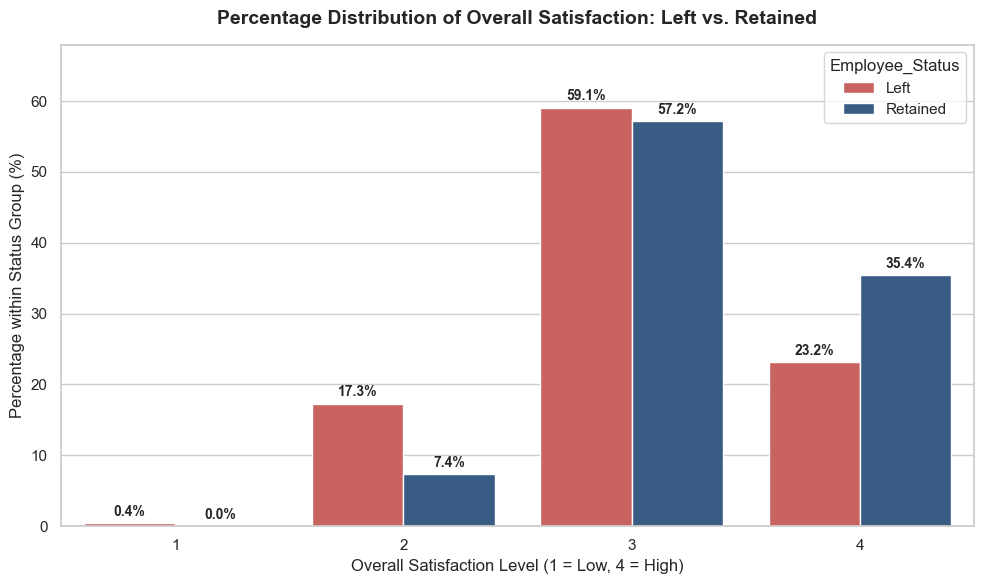

In [140]:
left_pct = employee_left['OverallSatisfaction'].value_counts(normalize=True).sort_index() * 100
retained_pct = employee_retaind['OverallSatisfaction'].value_counts(normalize=True).sort_index() * 100

# 3. Combine both series into a clean, long-format DataFrame for Seaborn plotting
# Ensure all levels (1 to 4) are represented, filling missing levels with 0%
levels = [1, 2, 3, 4]
data_list = []

for lvl in levels:
    data_list.append({
        'Satisfaction_Level': lvl,
        'Percentage': left_pct.get(lvl, 0.0),
        'Employee_Status': 'Left'
    })
    data_list.append({
        'Satisfaction_Level': lvl,
        'Percentage': retained_pct.get(lvl, 0.0),
        'Employee_Status': 'Retained'
    })

plot_df = pd.DataFrame(data_list)

# --- VISUALIZATION CODE ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the grouped bar chart
ax = sns.barplot(
    data=plot_df,
    x='Satisfaction_Level',
    y='Percentage',
    hue='Employee_Status',
    palette=['#d9534f', '#2b5c8f']  # Red for Left, Blue for Retained
)

plt.title('Percentage Distribution of Overall Satisfaction: Left vs. Retained', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Overall Satisfaction Level (1 = Low, 4 = High)', fontsize=12)
plt.ylabel('Percentage within Status Group (%)', fontsize=12)

# Expand Y-axis slightly so the text labels on top fit perfectly
max_pct = plot_df['Percentage'].max()
plt.ylim(0, max_pct * 1.15)

# Add exact percentage text labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

plt.tight_layout()
plt.show()

Now, let's see if there is a specific satisfaction score which drives most of the employees towards attrition.

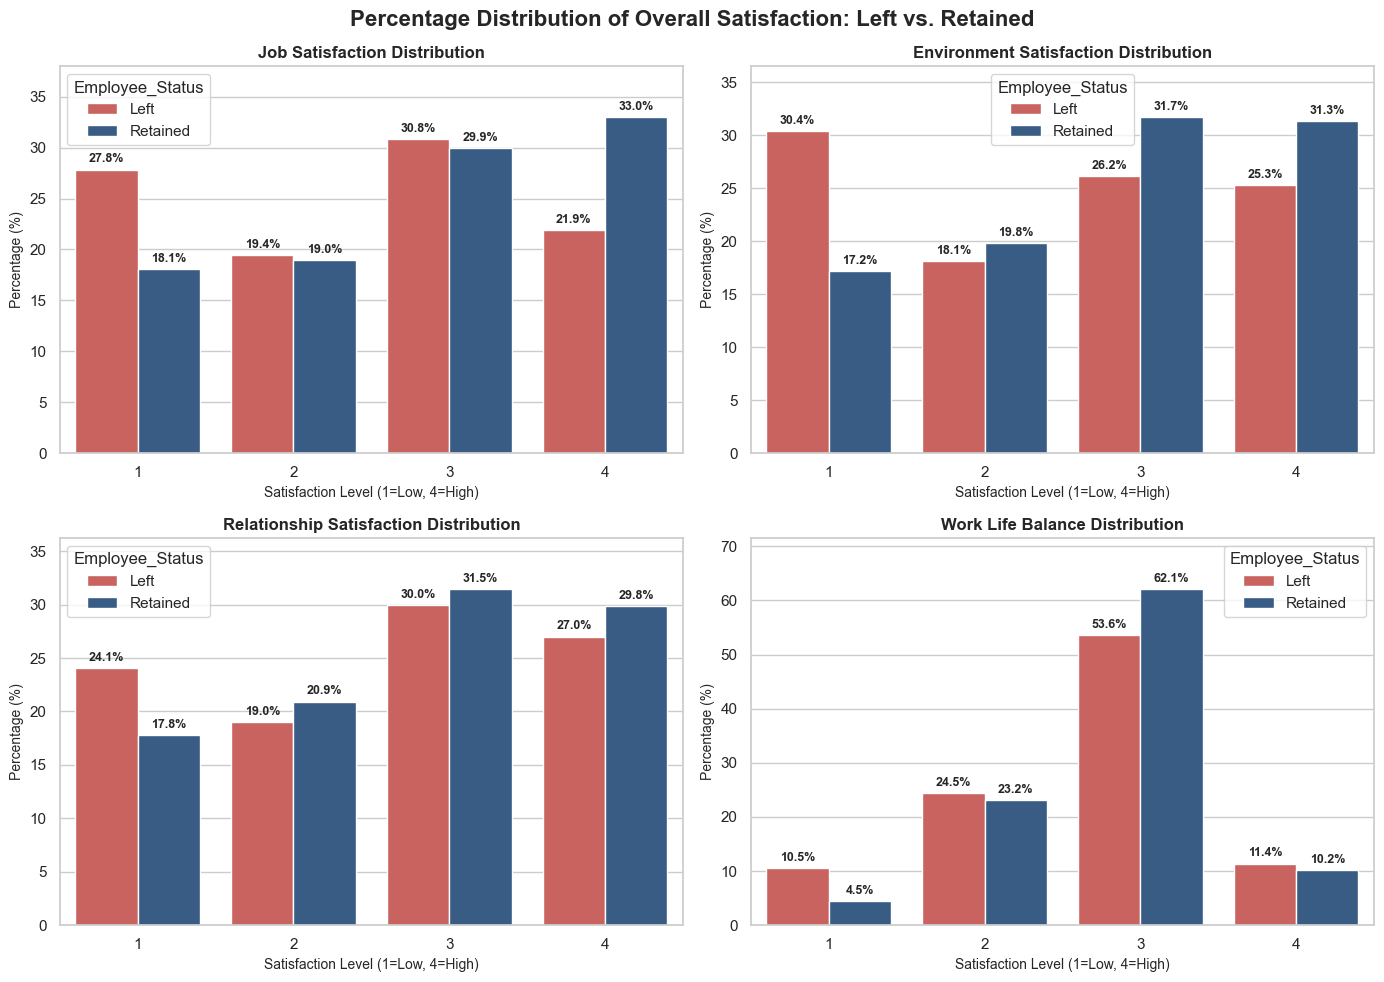

In [141]:
left_pct_job = employee_left['JobSatisfaction'].value_counts(normalize=True).sort_index() * 100
retained_pct_job= employee_retaind['JobSatisfaction'].value_counts(normalize=True).sort_index() * 100

left_pct_environment = employee_left['EnvironmentSatisfaction'].value_counts(normalize=True).sort_index() * 100
retained_pct_environment = employee_retaind['EnvironmentSatisfaction'].value_counts(normalize=True).sort_index() * 100

left_pct_relationship = employee_left['RelationshipSatisfaction'].value_counts(normalize=True).sort_index() * 100
retained_pct_relationship = employee_retaind['RelationshipSatisfaction'].value_counts(normalize=True).sort_index() * 100

left_pct_WorkLifeBalance = employee_left['WorkLifeBalance'].value_counts(normalize=True).sort_index() * 100
retained_pct_WorkLifeBalance = employee_retaind['WorkLifeBalance'].value_counts(normalize=True).sort_index() * 100


levels = [1, 2, 3, 4]
data_list = []

for lvl in levels:
    data_list.append({
        'Satisfaction_Level': lvl,
        'JobSatisfaction': left_pct_job.get(lvl, 0.0),
        'EnvironmentSatisfaction': left_pct_environment.get(lvl, 0.0),
        'RelationshipSatisfaction': left_pct_relationship.get(lvl, 0.0),
        'WorkLifeBalance': left_pct_WorkLifeBalance.get(lvl, 0.0), 
        'Employee_Status': 'Left'
    })
    data_list.append({
        'Satisfaction_Level': lvl,
        'JobSatisfaction': retained_pct_job.get(lvl, 0.0),
        'EnvironmentSatisfaction': retained_pct_environment.get(lvl, 0.0),
        'RelationshipSatisfaction': retained_pct_relationship.get(lvl, 0.0),
        'WorkLifeBalance': retained_pct_WorkLifeBalance.get(lvl, 0.0),
        'Employee_Status': 'Retained'
    })

plot_df = pd.DataFrame(data_list)

# --- VISUALIZATION  ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10)) # Increased size for readability
sns.set_theme(style="whitegrid")

metrics = [
    ('JobSatisfaction', axes[0, 0], 'Job Satisfaction'),
    ('EnvironmentSatisfaction', axes[0, 1], 'Environment Satisfaction'),
    ('RelationshipSatisfaction', axes[1, 0], 'Relationship Satisfaction'),
    ('WorkLifeBalance', axes[1, 1], 'Work Life Balance')
]

for column_name, ax, title_name in metrics:
    sns.barplot(
        data=plot_df,
        x='Satisfaction_Level',
        y=column_name,       
        hue='Employee_Status',
        palette=['#d9534f', '#2b5c8f'],
        ax=ax               
    )
    
    ax.set_title(f'{title_name} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Satisfaction Level (1=Low, 4=High)', fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    
    max_val = plot_df[column_name].max()
    ax.set_ylim(0, max_val * 1.15)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9, fontweight='bold', padding=3)

plt.suptitle('Percentage Distribution of Overall Satisfaction: Left vs. Retained', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Therefore, most of the employees who left said that the comapny has a good work life balance. But it is failed to provide good wokrplace, relationship, hight quality working environment, and preffered job role.

Now, let's if any other factors are affecting employee attrition.

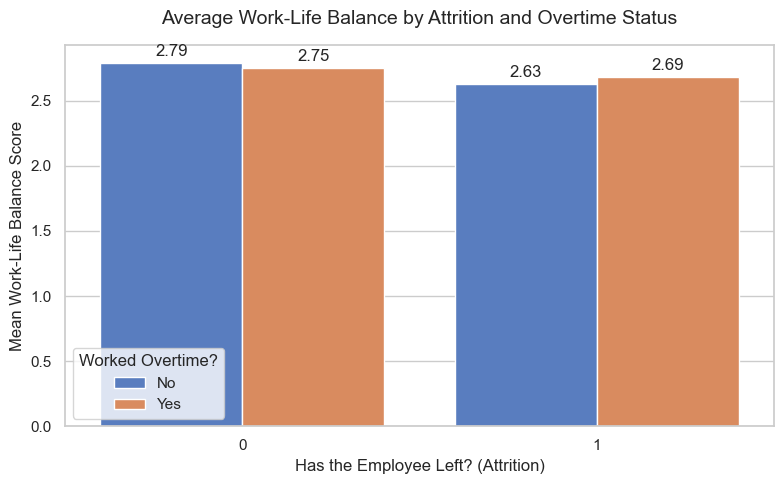

In [142]:

plt.figure(figsize=(8, 5))

# Create the grouped bar chart
ax = sns.barplot(
    data=employee, 
    x='Attrition', 
    y='WorkLifeBalance', 
    hue='OverTime', 
    palette='muted',
    errorbar=None  # Removes error bars for a cleaner look if desired
)

# Customize labels and titles for clarity
plt.title('Average Work-Life Balance by Attrition and Overtime Status', fontsize=14, pad=15)
plt.xlabel('Has the Employee Left? (Attrition)', fontsize=12)
plt.ylabel('Mean Work-Life Balance Score', fontsize=12)
plt.legend(title='Worked Overtime?')

# Add value labels on top of the bars for instant readability
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()


In [143]:
employee.groupby(['Attrition', 'OverTime'])['MonthlyIncome'].mean()

Attrition  OverTime
0          No          6669.690678
           Yes         7365.328720
1          No          4899.318182
           Yes         4689.889764
Name: MonthlyIncome, dtype: float64

This narrow 0.05 difference between the average work-life balance of overtimers and non-overtimers, reveals a critical "silent burnout" threat: employees who work overtime are masking their exhaustion by reporting high work-life balance scores on paper, right up until they quit. This suggests your standard surveys are failing as an early-warning system, either because employees lack the psychological safety to report true burnout, or because they view heavy overtime as a normal expectation. Consequently, their attrition is likely not triggered by the extra hours themselves, but by an unfair exchange—they willingly put in the overtime, but suddenly resign when that extra effort fails to translate into expected rewards, recognition, or promotions.

### Age

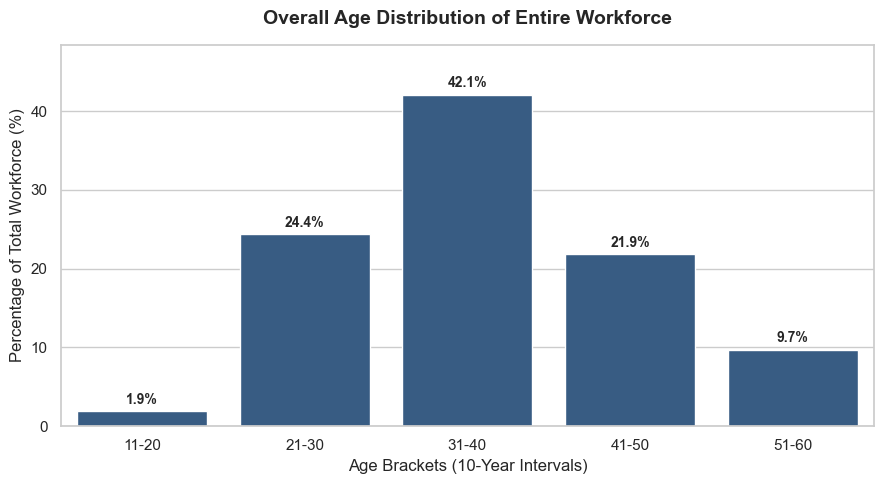

In [144]:
bin_edges = [10, 20, 30, 40, 50, 60]
bin_labels = ['11-20', '21-30', '31-40', '41-50', '51-60']
employee['Age_Group'] = pd.cut(employee['Age'], bins=bin_edges, labels=bin_labels)

overall_age_pct = (
    employee['Age_Group']
    .value_counts(normalize=True)   
    .mul(100)                     
    .rename('Percentage')
    .reset_index()                 
)
overall_age_pct = overall_age_pct.sort_values('Age_Group')

# --- VISUALIZATION ---
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=overall_age_pct, x='Age_Group', y='Percentage', color='#2b5c8f')
plt.title('Overall Age Distribution of Entire Workforce', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Brackets (10-Year Intervals)', fontsize=12)
plt.ylabel('Percentage of Total Workforce (%)', fontsize=12)
max_val = overall_age_pct['Percentage'].max()
plt.ylim(0, max_val * 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

plt.tight_layout()
plt.show()


Since, the company hires most people from the age group 31-40, calculating simple percentages will be biased towards this one. To analyse it fairly, we will calculate based on a hypothetical situation that is "if we hire from this age group how many will leave and how many will stay."

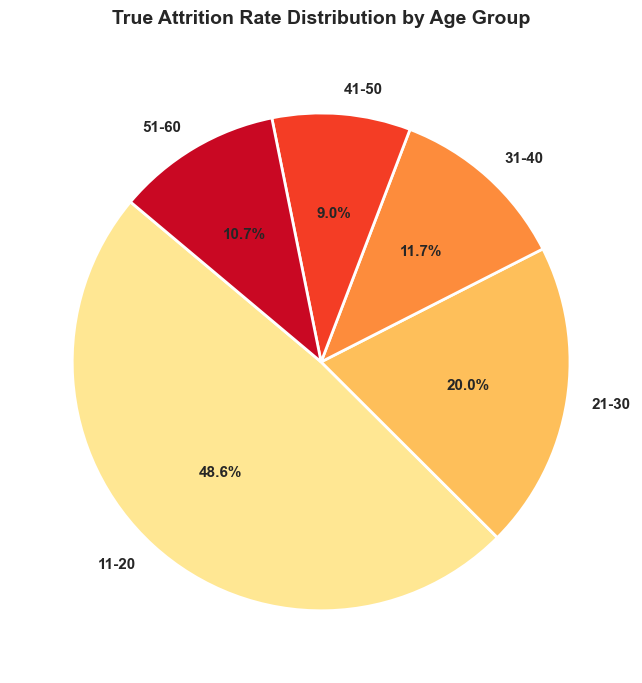

In [145]:
true_attrition_rates = (
    employee.groupby('Age_Group', observed=False)['Attrition']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition_Rate'})
)

# --- VISUALIZATION ---
colors = sns.color_palette("YlOrRd", len(true_attrition_rates))
plt.figure(figsize=(7, 7))
plt.pie(
    true_attrition_rates['Attrition_Rate'], 
    labels=true_attrition_rates['Age_Group'], 
    autopct='%.1f%%', 
    startangle=140, 
    colors=colors,
    textprops={'fontsize': 11, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('True Attrition Rate Distribution by Age Group', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Hence, young employees or freshers are more prone to attrition. This is logical as they are in the begining of their career and always look for better offers. We will se it further later.

In [146]:
# 1. Calculate the means for both groups under 30
u30_stayers = employee[(employee['Age'] < 30) & (employee['Attrition'] == 0)]
u30_leavers = employee[(employee['Age'] < 30) & (employee['Attrition'] == 1)]

metrics = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion']
labels = ['Company Tenure', 'Time in Current Role', 'Time Since Promotion']
indicators = ['Measures loyalty baseline', 'Highlights role lock-in', 'Direct stagnation trigger']

# 2. Print the Markdown Table Header
print(f"| {'Career Metric':<21} | {'Stayed (Under 30)':<20} | {'Left (Under 30)':<18} | {'The Stagnation Gap':<22} | {'Risk Indicator':<27} |")
print(f"|:{'-'*21} |:{'-'*20}:|:{'-'*18}:|:{'-'*22}:|:{'-'*27} |")

# 3. Calculate and populate the rows dynamically
for metric, label, indicator in zip(metrics, labels, indicators):
    mean_stayed = u30_stayers[metric].mean()
    mean_left = u30_leavers[metric].mean()
    gap = mean_stayed - mean_left  # Shows how much faster stayers advance/accumulate tenure
    
    print(f"| {label:<21} | {mean_stayed:<15.2f}years | {mean_left:<13.2f}years | {gap:<17.2f}years | {indicator:<27} |")


| Career Metric         | Stayed (Under 30)    | Left (Under 30)    | The Stagnation Gap     | Risk Indicator              |
|:--------------------- |:--------------------:|:------------------:|:----------------------:|:--------------------------- |
| Company Tenure        | 4.52           years | 2.82         years | 1.70             years | Measures loyalty baseline   |
| Time in Current Role  | 3.08           years | 1.85         years | 1.23             years | Highlights role lock-in     |
| Time Since Promotion  | 1.00           years | 0.95         years | 0.05             years | Direct stagnation trigger   |


### Income

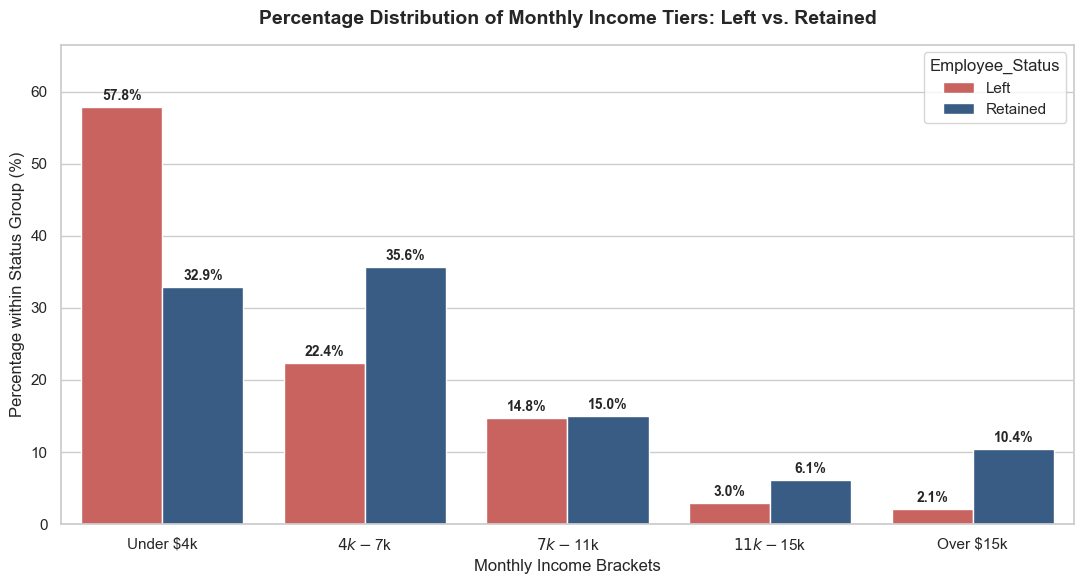

In [147]:
income_bins = [1000, 4000, 7000, 11000, 15000, 20000]
income_labels = ['Under $4k', '$4k - $7k', '$7k - $11k', '$11k - $15k', 'Over $15k']
employee['Income_Tier'] = pd.cut(employee['MonthlyIncome'], bins=income_bins, labels=income_labels)

employee_left = employee[employee['Attrition'] == 1]
employee_retained = employee[employee['Attrition'] == 0]
left_pct_inc = employee_left['Income_Tier'].value_counts(normalize=True).mul(100)
retained_pct_inc = employee_retained['Income_Tier'].value_counts(normalize=True).mul(100)
data_list = []
for label in income_labels:
    data_list.append({
        'Income_Tier': label,
        'Percentage': left_pct_inc.get(label, 0.0),
        'Employee_Status': 'Left'
    })
    data_list.append({
        'Income_Tier': label,
        'Percentage': retained_pct_inc.get(label, 0.0),
        'Employee_Status': 'Retained'
    })

plot_df = pd.DataFrame(data_list)

# --- 5. VISUALIZATION CODE ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=plot_df,
    x='Income_Tier',
    y='Percentage',
    hue='Employee_Status',
    palette=['#d9534f', '#2b5c8f'] 
)

plt.title('Percentage Distribution of Monthly Income Tiers: Left vs. Retained', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Monthly Income Brackets', fontsize=12)
plt.ylabel('Percentage within Status Group (%)', fontsize=12)

max_pct = plot_df['Percentage'].max()
plt.ylim(0, max_pct * 1.15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

plt.tight_layout()
plt.show()

Most of the employees who left had a problem with their monthly income. Now, let's see what is the difference between their take home salary and monthly rate(CTC).

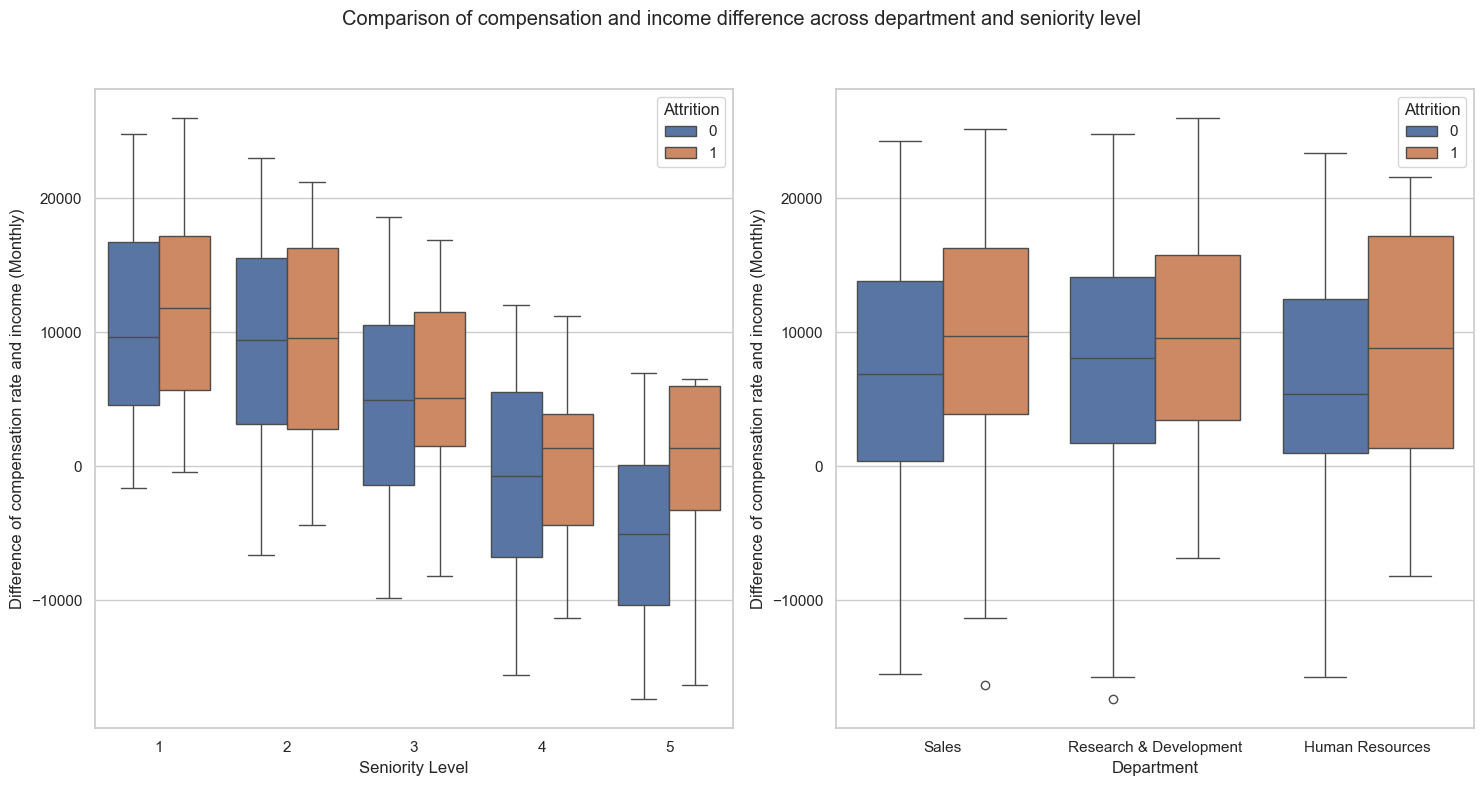

In [148]:
employee['CompensationIncomeDifference']=  employee['MonthlyRate'] - employee['MonthlyIncome']

fig, ax= plt.subplots(1,2, figsize= (15,8))

sns.boxplot(data= employee, x= 'JobLevel', y= 'CompensationIncomeDifference', hue= 'Attrition', ax= ax[0])
ax[0].set_xlabel("Seniority Level")
ax[0].set_ylabel("Difference of compensation rate and income (Monthly)")

sns.boxplot(data= employee, x= 'Department', y= 'CompensationIncomeDifference', hue= 'Attrition', ax= ax[1])
ax[1].set_xlabel("Department")
ax[1].set_ylabel("Difference of compensation rate and income (Monthly)")

plt.suptitle("Comparison of compensation and income difference across department and seniority level")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Across all three departments (Sales, R&D, and HR), the orange boxes (Leavers) consistently sit higher on the Y-axis than the blue boxes (Retained). i.e. Those leaving earn substantially lower amounts of real monthly salary as compared to their allotted salary levels than those who opt to remain with the company.
Also, Senior employees (level 5) are highly sensitive when it comes to compensation alignment. Senior employees who believe that they are being underpaid in comparison to their retained peers (whom they believe are receiving substantial compensation) pose a serious threat of flight risk.

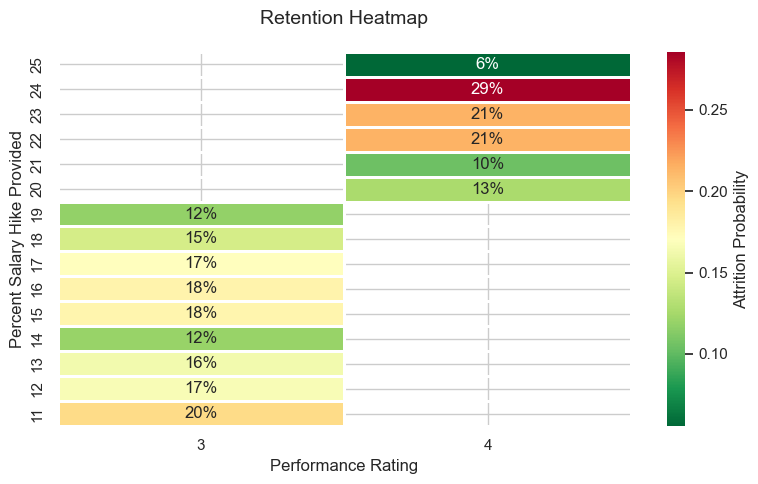

In [149]:
heatmap_data = employee.pivot_table(
    index='PercentSalaryHike', 
    columns='PerformanceRating', 
    values='Attrition', 
    aggfunc='mean'
).sort_index(ascending=False) # High hikes on top

# 2. Plot the Heatmap
plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    heatmap_data, 
    annot=True,       # Show the exact attrition rate in the cell
    fmt='.0%',        # Format as percentage (e.g., 25%)
    cmap='RdYlGn_r',  # Red = High Attrition (Bad), Green = Low Attrition (Good)
    linewidths=1, 
    linecolor='white',
    cbar_kws={'label': 'Attrition Probability'}
)

# 3. Aesthetics for Executive Presentation
plt.title('Retention Heatmap', fontsize=14, pad=20)
plt.ylabel('Percent Salary Hike Provided', fontsize=12)
plt.xlabel('Performance Rating', fontsize=12)

# Highlight the "Incentive Mismatch" zone (High Perf / Low Hike)
# This box draws the eye to the specific problem area
from matplotlib.patches import Rectangle
# Adjust these coordinates (x, y, width, height) based on your specific data grid
# Example: Highlighting Performance Rating 3 & 4 with Hikes 11-15% (bottom right)
# ax.add_patch(Rectangle((2, 10), 2, 5, fill=False, edgecolor='blue', lw=4, clip_on=False))

plt.tight_layout()
plt.show()

This heatmap exposes a critical "Retention Paradox" among your highest performers. Most alarming is a severe retention cliff for elite workers (Performance Rating 4). Receiving a massive 24% salary hike triggers the highest attrition rate on the chart at 29%. This indicates that these delayed corrections come too late, or instead serve to amplify the employee's external market value. Risk only stabilizes—dropping dramatically to 6%—when hitting the absolute 25% maximum ceiling. Meanwhile, for standard high performers (Performance Rating 3), a low 11% hike sparks a dangerous 20% flight risk. Furthermore, mid-tier adjustments between 15% and 18% offer no incremental retention benefit, keeping attrition trapped in a costly 17% to 18% dead zone.

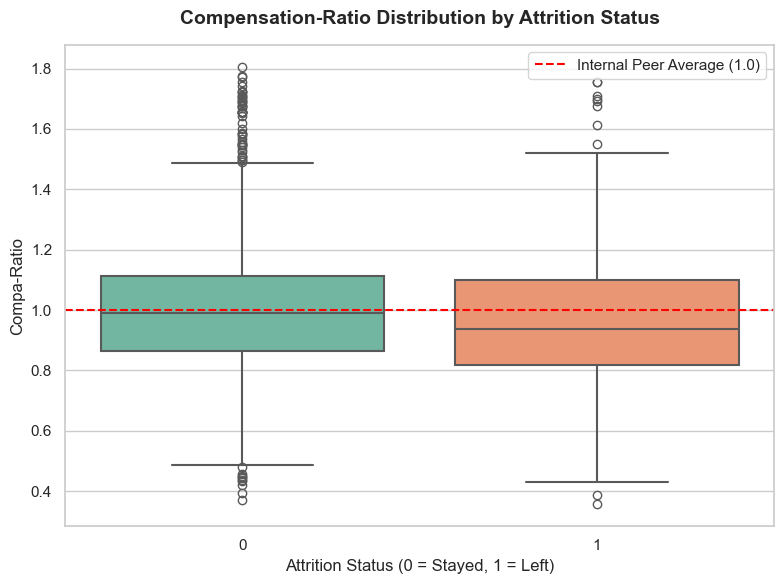

In [150]:
role_level_avg = employee.groupby(['JobRole', 'JobLevel'])['MonthlyIncome'].transform('mean')
employee['CompensationRatio'] = employee['MonthlyIncome'] / role_level_avg

# 2. Plot configuration
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Create a formal box plot comparing Compa-Ratio by Attrition status
ax = sns.boxplot(
    data=employee,
    x='Attrition',
    y='CompensationRatio',
    hue='Attrition',
    legend=False,
    palette='Set2',
    linewidth=1.5
)

# 3. Industry Baseline Reference Line
# A Compa-Ratio of 1.0 is the exact peer average. A reference line makes deviations obvious.
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Internal Peer Average (1.0)')
plt.legend(loc='upper right')

# 4. Formal Aesthetics
plt.title('Compensation-Ratio Distribution by Attrition Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attrition Status (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Compa-Ratio', fontsize=12)

plt.tight_layout()
plt.show()

This box plot reveals a distinct internal pay equity gap that heavily drives employee attrition. For employees who stayed (0), the median Compa-Ratio sits almost exactly at the 1.0 peer average, indicating fair alignment with internal compensation standards. Conversely, for employees who left (1), the median Compa-Ratio drops significantly below the benchmark to roughly 0.94, with a large portion of this cohort falling into the critical underpayment zone below 0.82. This clear downward shift mathematically confirms that employees who are undercompensated relative to peers in the exact same role and job level face a substantially higher flight risk.

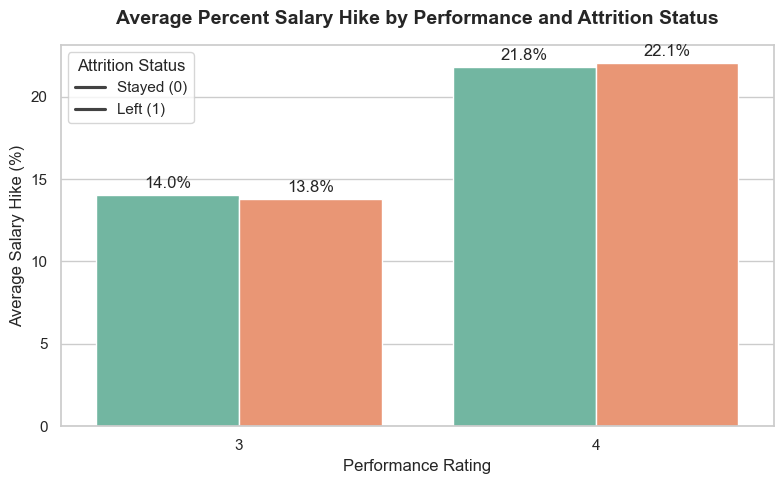

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reset index if needed to prepare data for Seaborn plotting
# This ensures the groupby object can be parsed correctly by the barplot
perf_hike_df = employee.groupby(['PerformanceRating', 'Attrition'])['PercentSalaryHike'].mean().reset_index()

# 2. Plot configuration
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Create a clean grouped bar chart
ax = sns.barplot(
    data=perf_hike_df,
    x='PerformanceRating',
    y='PercentSalaryHike',
    hue='Attrition',
    palette='Set2'
)

# 3. Formal Aesthetics
plt.title('Average Percent Salary Hike by Performance and Attrition Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Performance Rating', fontsize=12)
plt.ylabel('Average Salary Hike (%)', fontsize=12)

# Professional Legend Labels
plt.legend(title='Attrition Status', labels=['Stayed (0)', 'Left (1)'])

# Add exact value labels on top of each bar for precision
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

So, average salary hike for both who left and stayed are fair according to their  performance. i.e. this is not a direct driver of attrition of employees.

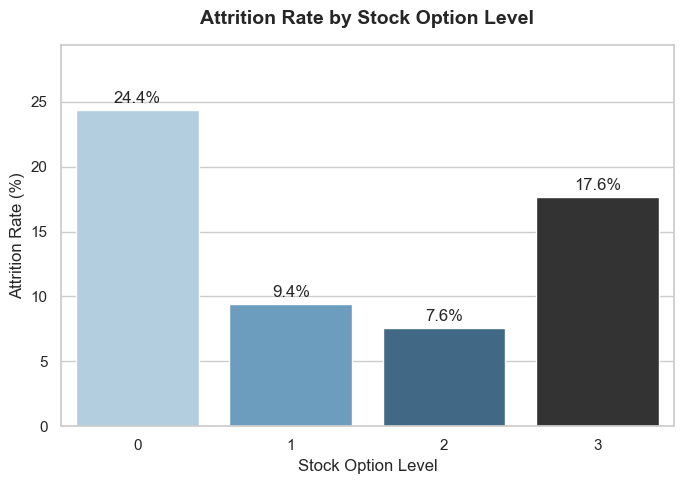

In [152]:
stock_attrition_df = (
    employee.groupby('StockOptionLevel')['Attrition'].mean() * 100
).reset_index()

# 2. Plot configuration
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# Create the formal vertical bar chart with non-white sequential shading
ax = sns.barplot(
    data=stock_attrition_df,
    x='StockOptionLevel',
    y='Attrition',
    hue='StockOptionLevel', 
    legend=False,           
    palette='Blues_d',      # Shifted to a darker blue palette to prevent white bars
    errorbar=None
)

# 3. Formal Aesthetics
plt.title('Attrition Rate by Stock Option Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Stock Option Level', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.ylim(0, max(stock_attrition_df['Attrition']) + 5)

# Add exact percentage labels to the top of each bar for precision
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

The chart validates that offering employees baseline equity (Level 1 and Level 2) helps retain employees effectively, with attrition kept below 10%. When employees have zero equity, there is zero exit barrier for them, and hence, such employees carry the greatest risk of attrition, amounting to 24.4%, since they have little financial motivation to stay loyal. Nevertheless, while the second peak of attrition, which is 17.6% at level 3, may seem like low employee satisfaction with their stock value, this may instead be a case of top executives vesting their options or elite employees being lured away by competitors.

### Growth

Now, let's see what is the growth looks like in this company.

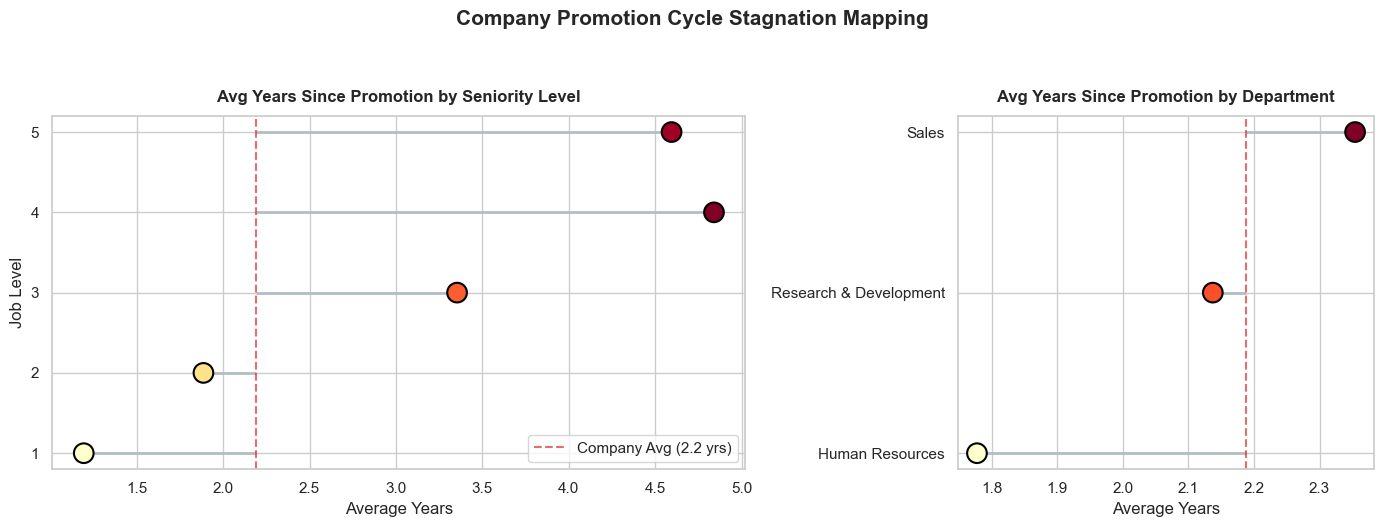

In [153]:
promotion_by_seniority= (employee.groupby('JobLevel')['YearsSinceLastPromotion'].mean().reset_index(name='YearsSinceLastPromotion'))
promotion_by_department= (employee.groupby('Department')['YearsSinceLastPromotion'].mean().reset_index(name='YearsSinceLastPromotion'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [5, 3]})
global_mean = employee['YearsSinceLastPromotion'].mean()

df_level = promotion_by_seniority.sort_values(by='JobLevel')
axes[0].hlines(y=df_level['JobLevel'], xmin=global_mean, xmax=df_level['YearsSinceLastPromotion'], 
               color='#b2bec3', linewidth=2, zorder=1)
scatter1 = axes[0].scatter(df_level['YearsSinceLastPromotion'], df_level['JobLevel'], 
                           s=200, c=df_level['YearsSinceLastPromotion'], cmap='YlOrRd', 
                           edgecolors='black', linewidths=1.5, zorder=2)
axes[0].axvline(global_mean, color='#d63031', linestyle='--', alpha=0.7, label=f'Company Avg ({global_mean:.1f} yrs)')
axes[0].set_yticks(df_level['JobLevel'])
axes[0].set_title('Avg Years Since Promotion by Seniority Level', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Average Years')
axes[0].set_ylabel('Job Level')
axes[0].legend()

df_dept = promotion_by_department.sort_values(by='YearsSinceLastPromotion')
axes[1].hlines(y=df_dept['Department'], xmin=global_mean, xmax=df_dept['YearsSinceLastPromotion'], 
               color='#b2bec3', linewidth=2, zorder=1)
scatter2 = axes[1].scatter(df_dept['YearsSinceLastPromotion'], df_dept['Department'], 
                           s=200, c=df_dept['YearsSinceLastPromotion'], cmap='YlOrRd', 
                           edgecolors='black', linewidths=1.5, zorder=2)
axes[1].axvline(global_mean, color='#d63031', linestyle='--', alpha=0.7)
axes[1].set_title('Avg Years Since Promotion by Department', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Average Years')

plt.suptitle('Company Promotion Cycle Stagnation Mapping', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

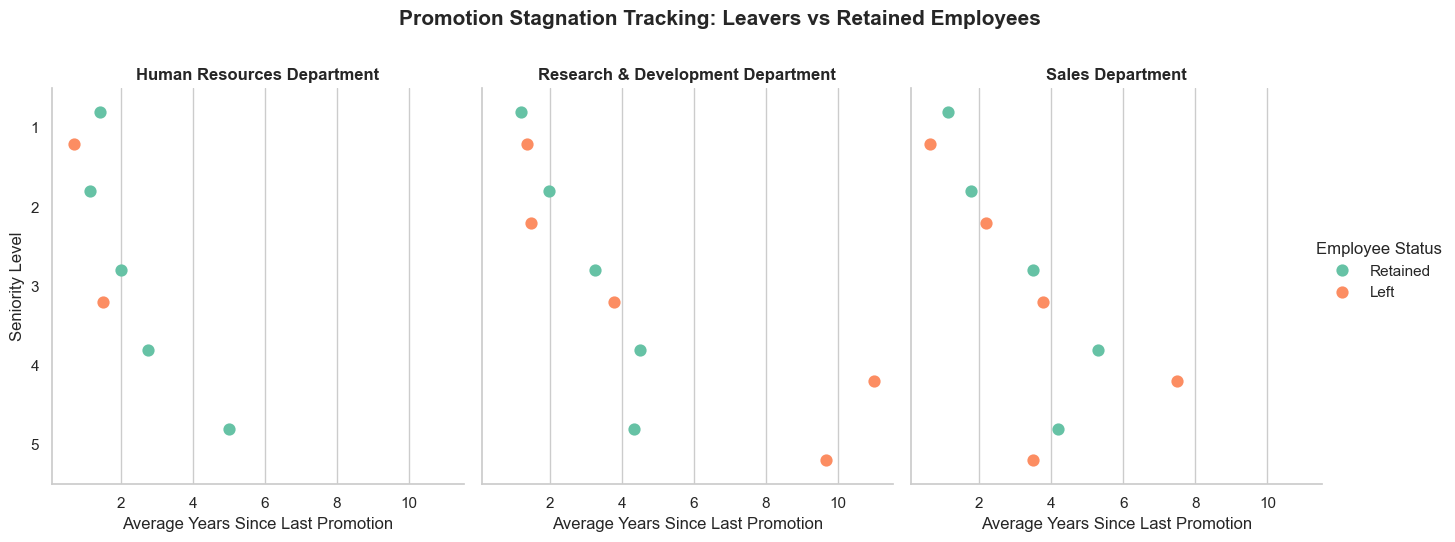

In [154]:
promo_analysis = (employee.groupby(['Department', 'JobLevel', 'Attrition'])['YearsSinceLastPromotion']
                  .mean()
                  .reset_index(name='AvgYears'))

# Map Attrition numeric flags to human-readable strings for clear presentation legend
promo_analysis['Status'] = promo_analysis['Attrition'].map({0: 'Retained', 1: 'Left'})

# Use sns.catplot instead of manual FacetGrid to prevent the mapping bug
g = sns.catplot(
    data=promo_analysis,
    kind="point",         # Tells seaborn to use pointplot / lollipop style
    x="AvgYears", 
    y="JobLevel", 
    col="Department", 
    hue="Status", 
    palette="Set2",
    orient="h", 
    dodge=0.4,            # Shifts Retained vs Left slightly apart
    linestyle="none",     # Extra protection against connecting lines
    height=5, 
    aspect=0.9, 
    sharey=True
)

# Fine-tune labels and clean graph layout geometry
g.set_axis_labels("Average Years Since Last Promotion", "Seniority Level")
g.set_titles(col_template="{col_name} Department", weight='bold', size=12)
g.legend.set_title("Employee Status")

# Add a global master title above the grid panels
plt.suptitle("Promotion Stagnation Tracking: Leavers vs Retained Employees", fontsize=15, fontweight='bold', y=1.08)

plt.show()

So, we can see that promotion alone is not a direct driver of attrition, since the promotion of employees who left or who didn't are according to company rules and tradition. Let's if how much hike they got in last apprisal.

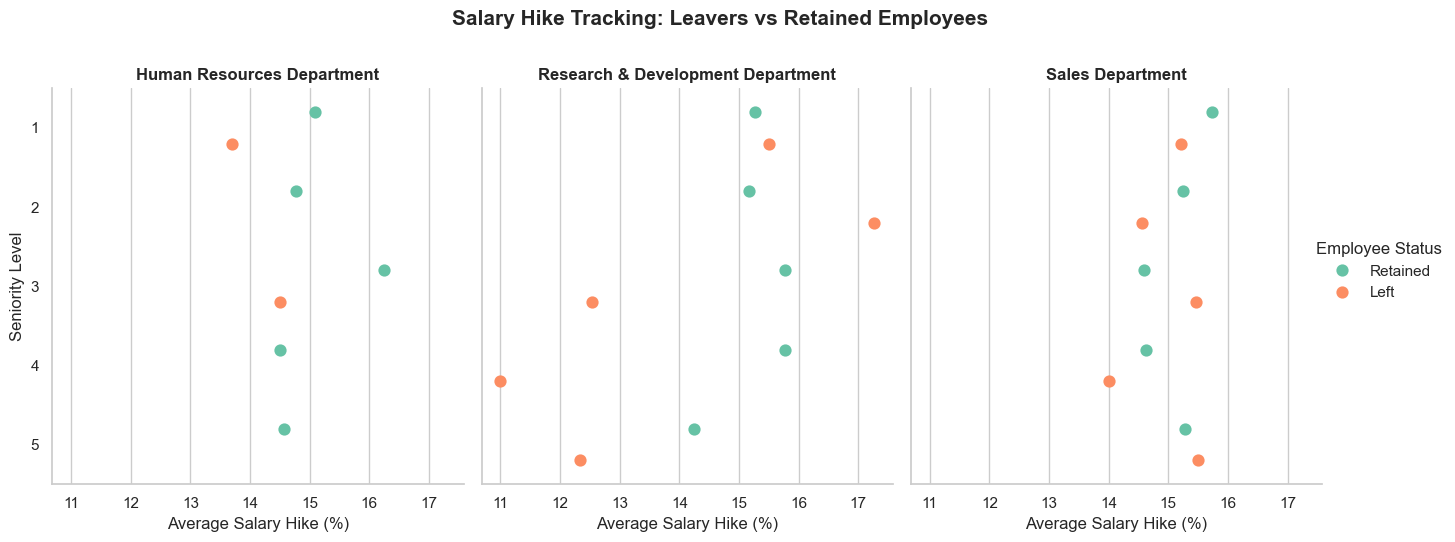

In [155]:
hike_analysis = (employee.groupby(['Department', 'JobLevel', 'Attrition'])['PercentSalaryHike']
                 .mean()
                 .reset_index(name='AvgSalaryHike'))  # Renamed to reflect salary hike

# Map Attrition numeric flags to human-readable strings for clear presentation legend
hike_analysis['Status'] = hike_analysis['Attrition'].map({0: 'Retained', 1: 'Left'})

# Use sns.catplot to plot salary hike distributions side-by-side
g = sns.catplot(
    data=hike_analysis,
    kind="point",         
    x="AvgSalaryHike",    # Updated to your new column name
    y="JobLevel", 
    col="Department", 
    hue="Status", 
    palette="Set2",
    orient="h", 
    dodge=0.4,            
    linestyle="none",     
    height=5, 
    aspect=0.9, 
    sharey=True
)

# Fine-tune labels to reflect percentages
g.set_axis_labels("Average Salary Hike (%)", "Seniority Level")
g.set_titles(col_template="{col_name} Department", weight='bold', size=12)
g.legend.set_title("Employee Status")

# Add a global master title reflecting compensation trends
plt.suptitle("Salary Hike Tracking: Leavers vs Retained Employees", fontsize=15, fontweight='bold', y=1.08)

plt.show()

While, sales personals aren'y leaving for hike issue, but in HR and R&D department, there is in equality issue rgarding hikes. Employees who left got on an average 2-3% less hike, even being in same seniority level and department. Let's look at their performance score, to judge if that was fair or not. 

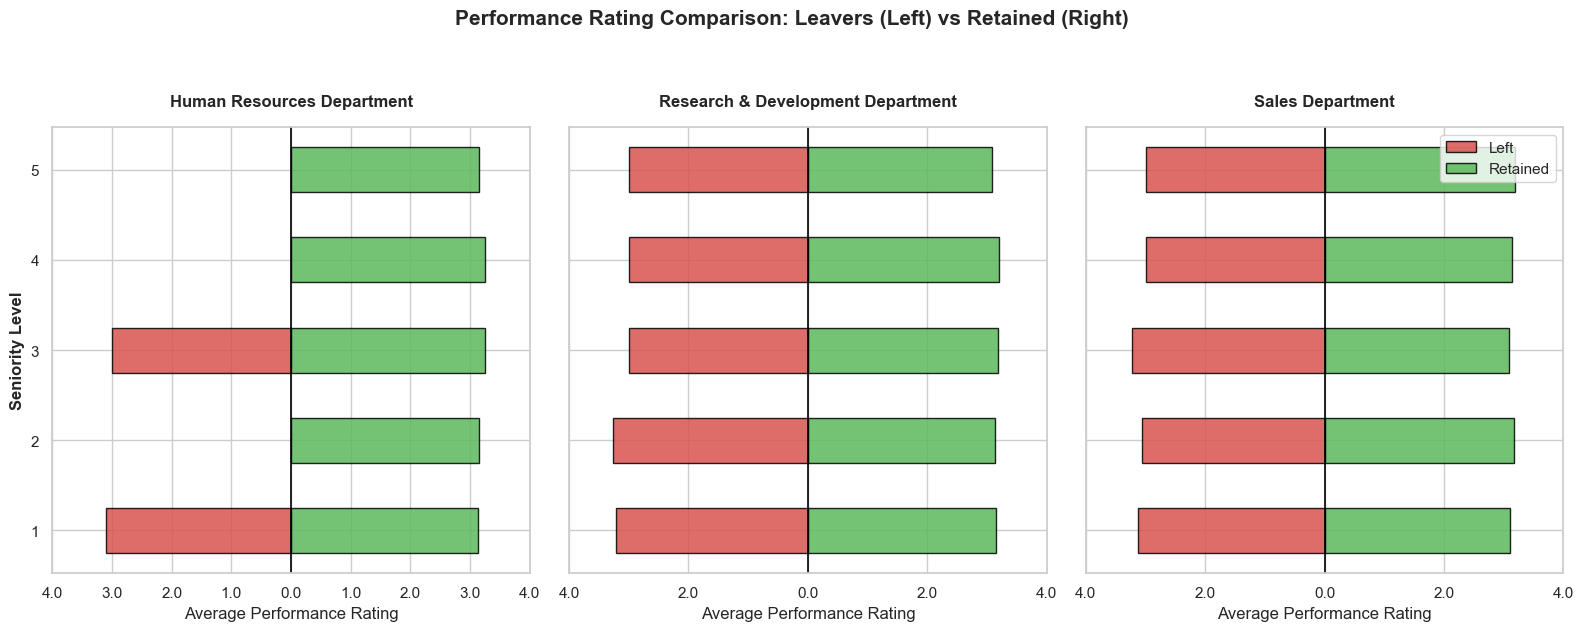

In [156]:
perf_analysis = (employee.groupby(['Department', 'JobLevel', 'Attrition'])['PerformanceRating']
                 .mean()
                 .reset_index(name='AvgRating'))

departments = perf_analysis['Department'].unique()
fig, axes = plt.subplots(1, len(departments), figsize=(16, 6), sharey=True)

color_left = '#d9534f'   # Warm red/coral for Leavers
color_right = '#5cb85c'  # Clean green for Retained

for i, dept in enumerate(departments):
    ax = axes[i]
    dept_df = perf_analysis[perf_analysis['Department'] == dept]
    left_data = dept_df[dept_df['Attrition'] == 1].sort_values('JobLevel')
    retained_data = dept_df[dept_df['Attrition'] == 0].sort_values('JobLevel')
    
    # --- LEFT SIDE: Leavers (Invert values to push bars left) ---
    ax.barh(left_data['JobLevel'], -left_data['AvgRating'], 
            color=color_left, edgecolor='black', alpha=0.85, label='Left', height=0.5)
    
    # --- RIGHT SIDE: Retained (Positive values push bars right) ---
    ax.barh(retained_data['JobLevel'], retained_data['AvgRating'], 
            color=color_right, edgecolor='black', alpha=0.85, label='Retained', height=0.5)
    
    ax.set_title(f"{dept} Department", fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("Average Performance Rating")
    ax.set_yticks(range(1, 6))
    ticks = ax.get_xticks()
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{abs(t):.1f}" for t in ticks])
    ax.axvline(0, color='black', linewidth=1.2, linestyle='-')

axes[0].set_ylabel("Seniority Level", fontsize=12, fontweight='bold')
axes[-1].legend(loc='upper right', frameon=True)

plt.suptitle("Performance Rating Comparison: Leavers (Left) vs Retained (Right)", 
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

It proves that performance was uniform, but compensation rewards were highly skewed. Employees didn't leave because they were bad workers; they left because the company's reward system failed to fairly compensate equal performance.

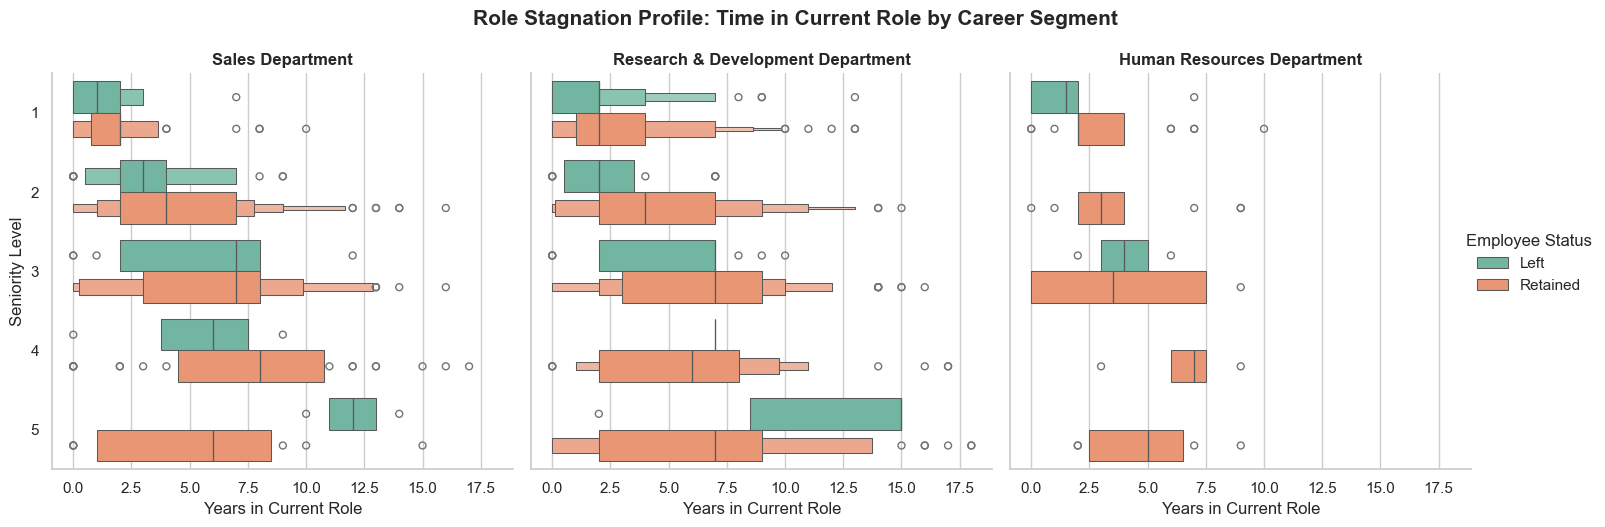

In [157]:
role_analysis = employee.copy()
role_analysis['Status'] = role_analysis['Attrition'].map({0: 'Retained', 1: 'Left'})
role_analysis['JobLevel'] = role_analysis['JobLevel'].astype(str)

g = sns.catplot(
    data=role_analysis,
    kind="boxen",         # Using Boxen/Letter-Value plot layout
    x="YearsInCurrentRole", 
    y="JobLevel", 
    col="Department", 
    hue="Status", 
    palette="Set2",       # Preserving your clean green/orange presentation palette
    orient="h", 
    height=5, 
    aspect=1.0, 
    sharey=True,
    order=sorted(role_analysis['JobLevel'].unique()) # Ensures Job Levels 1 to 5 stack nicely
)

g.set_axis_labels("Years in Current Role", "Seniority Level")
g.set_titles(col_template="{col_name} Department", weight='bold', size=12)
g.legend.set_title("Employee Status")
plt.suptitle("Role Stagnation Profile: Time in Current Role by Career Segment", 
             fontsize=15, fontweight='bold', y=1.05)
plt.show()

- Junior HR staff leave early because they are undercompensated (MonthlyRate > MonthlyIncome) and shortchanged on salary hikes.
- Mid-level Sales staff leave because their promotion cycles are completely frozen (~7.5-year promotion delay).
- Senior Executives (Level 5) in Sales and R&D leave because of pure role stagnation—they spend 12 to 15 years doing the exact same job without any career variation.

For the third one we can't do anything. But for the first two reasons the company should take necessary actions.

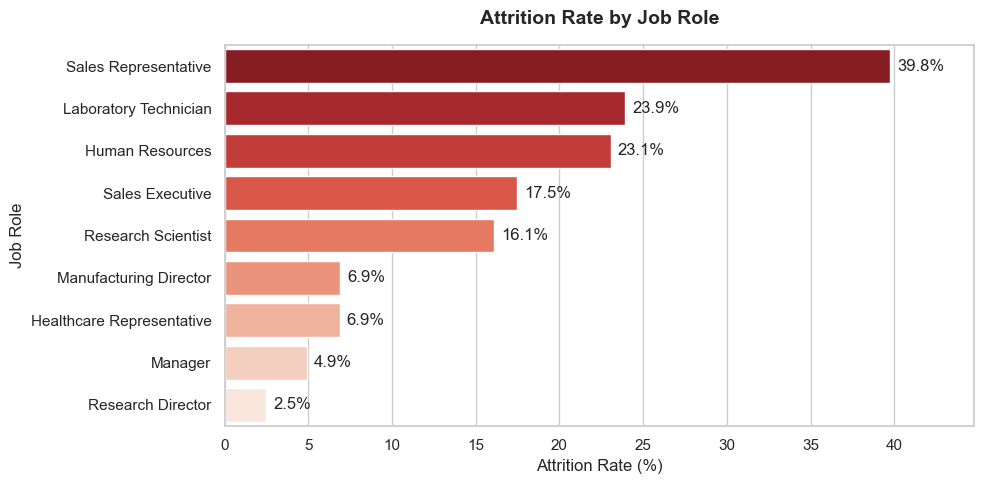

In [158]:
attrition_by_role = (
    employee.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100
).reset_index()

# 2. Plot configuration
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Updated to include hue and legend parameters to resolve the deprecation warning
ax = sns.barplot(
    data=attrition_by_role,
    x='Attrition',
    y='JobRole',
    hue='JobRole',    # Assigning the y variable to hue
    legend=False,     # Disabling the redundant legend
    palette='Reds_r', 
    errorbar=None
)

# 3. Formal Aesthetics
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attrition Rate (%)', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.xlim(0, max(attrition_by_role['Attrition']) + 5)

# Add exact percentage labels to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

plt.tight_layout()
plt.show()

This chart demonstrates that organizational attrition is heavily concentrated in entry-level, execution-focused roles rather than distributed uniformly. Sales Representatives present a critical operational threat with a massive 39.8% attrition rate, which is nearly double that of any other role and strongly indicates severe burnout or broken incentive structures. A secondary high-risk cluster exists among Laboratory Technicians (23.9%) and Human Resources (23.1%), followed closely by Sales Executives (17.5%) and Research Scientists (16.1%). Conversely, leadership tracks show exceptional stability, with Managers (4.9%) and Research Directors (2.5%) exhibiting minimal turnover, proving that retention risk drops dramatically as employees ascend into strategic, highly compensated role.

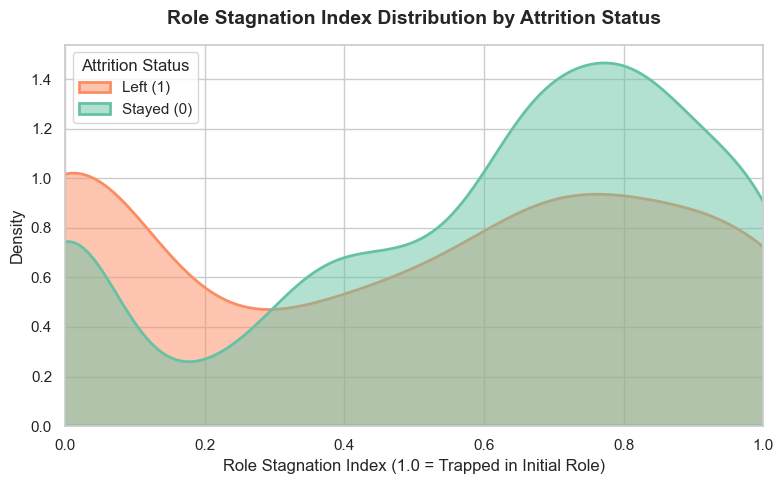

In [159]:
employee['RoleStagnationIndex'] = employee['YearsInCurrentRole'] / (employee['YearsAtCompany'] + 1e-5)

# 2. Plot configuration
plt.figure(figsize=(8, 5))

# Create a formal split KDE plot to show probability density over the index range
sns.kdeplot(
    data=employee,
    x='RoleStagnationIndex',
    hue='Attrition',
    fill=True,
    common_norm=False, # Normalizes each group independently to clearly compare shapes
    palette='Set2',
    alpha=0.5,
    linewidth=2
)

# 3. Formal Aesthetics
plt.title('Role Stagnation Index Distribution by Attrition Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Role Stagnation Index (1.0 = Trapped in Initial Role)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Professional Legend Labels
plt.legend(title='Attrition Status', labels=['Left (1)', 'Stayed (0)'])
plt.xlim(0, 1.0) # The index is naturally bounded between 0 and 1

plt.tight_layout()
plt.show()

Here we have evidence of the unexpected attrition trend, where the probability of being a leaver (orange) is higher at the 0.0 level and shows how important "the change shock" phenomenon is, meaning that **people leave work right after receiving another position or having been promoted.** On the contrary, in the "high stagnation" area (0.6-1.0), the number of stayers surpasses that of leavers. This means that **long-term role stability is quite acceptable for the remaining personnel.**

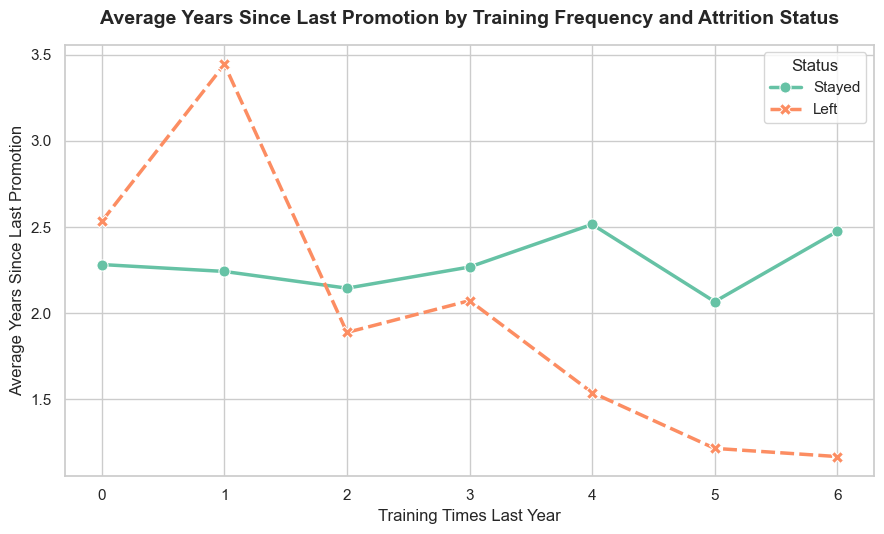

In [160]:
training_promo_df = employee.groupby(['TrainingTimesLastYear', 'Attrition'])['YearsSinceLastPromotion'].mean().reset_index()
training_promo_df['Attrition'] = training_promo_df['Attrition'].map({0: 'Stayed', 1: 'Left'})

# 2. Plot configuration
plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")

# Create a clean line plot
ax = sns.lineplot(
    data=training_promo_df,
    x='TrainingTimesLastYear',
    y='YearsSinceLastPromotion',
    hue='Attrition',
    style='Attrition', 
    markers=True,      
    markersize=8,
    linewidth=2.5,
    palette={'Stayed': '#66c2a5', 'Left': '#fc8d62'} # Explicitly map professional colors
)

# 3. Formal Aesthetics
plt.title('Average Years Since Last Promotion by Training Frequency and Attrition Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Times Last Year', fontsize=12)
plt.ylabel('Average Years Since Last Promotion', fontsize=12)

# Clean, single-title simplified legend override
plt.legend(title='Status', loc='upper right')

# Ensure all discrete training count integers are labeled on X-axis
plt.xticks(sorted(training_promo_df['TrainingTimesLastYear'].unique()))

plt.tight_layout()
plt.show()

employees with minimal training (0–1 sessions) leave due to promotional stagnation, peaking at nearly 3.5 years without advancement. Conversely, heavily trained employees (4–6 sessions) who leave do so despite very recent promotions, averaging under 1.5 years since their last advancement. This indicates that intensive upskilling combined with immediate promotion drastically spikes an employee's external market value, accelerating their departure through competitive poaching rather than fostering internal loyalty.

### Office Politics

The main driver in this segment is tixic manager. So, let's see it in detail.

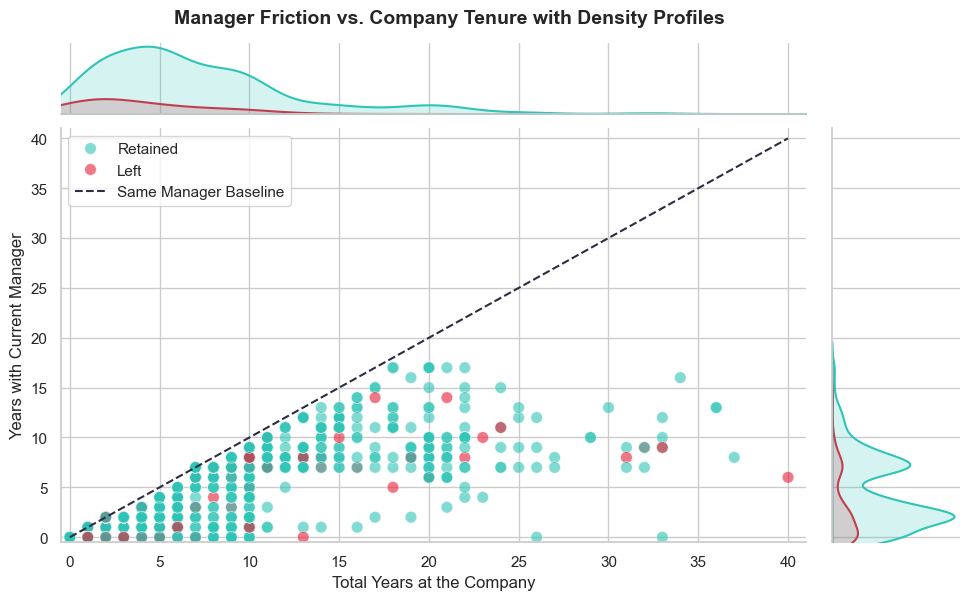

In [161]:
palette = {0: '#2ec4b6', 1: '#e71d36'}

# Use JointGrid to create a synchronized layout for scatter + density plots
g = sns.JointGrid(
    data=employee, 
    x='YearsAtCompany', 
    y='YearsWithCurrManager', 
    hue='Attrition', 
    palette=palette,
    height=5  # Keeps the aspect ratio perfectly square
)
g.fig.set_size_inches(11, 6)
# 1. Plot the central scatter points onto the main axis (ax_joint)
g.plot_joint(
    sns.scatterplot, 
    alpha=0.6, 
    s=70, 
    edgecolor='w', 
    linewidth=0.5
)

# 2. Plot the marginal density curves (KDE) on the outer top and right axes
g.plot_marginals(
    sns.kdeplot, 
    fill=True,       # Fills the area under the density curves
    alpha=0.2,       # Transparent fill to see overlapping peaks
    linewidth=1.5
)

# 3. Calculate max bounds dynamically
max_val = max(employee['YearsAtCompany'].max(), employee['YearsWithCurrManager'].max())

# 4. Draw the critical insight baseline directly onto the central axis
g.ax_joint.plot(
    [0, max_val], [0, max_val], 
    color='#2b2d42', linestyle='--', linewidth=1.5, 
    label='Same Manager Baseline'
)

# 5. Apply limits and clear labels to the core chart coordinates
g.ax_joint.set_xlim(-0.5, max_val + 1)
g.ax_joint.set_ylim(-0.5, max_val + 1)
g.ax_joint.set_xlabel("Total Years at the Company", fontsize=12)
g.ax_joint.set_ylabel("Years with Current Manager", fontsize=12)

# 6. Safely format the legend text in the correct plotting order
handles, labels = g.ax_joint.get_legend_handles_labels()
for i, label in enumerate(labels):
    if label == '0':
        labels[i] = 'Retained'
    elif label == '1':
        labels[i] = 'Left'

g.ax_joint.legend(handles, labels, loc='upper left', frameon=True)

# Main superior title placement above the joint layout grid
plt.suptitle("Manager Friction vs. Company Tenure with Density Profiles", 
             fontsize=14, fontweight='bold', y=1.02)

plt.show()

The manager is a major part of the problem, specifically during leadership transitions. Employees across all tenure levels are highly vulnerable to quitting during their first 24 months under a new supervisor.

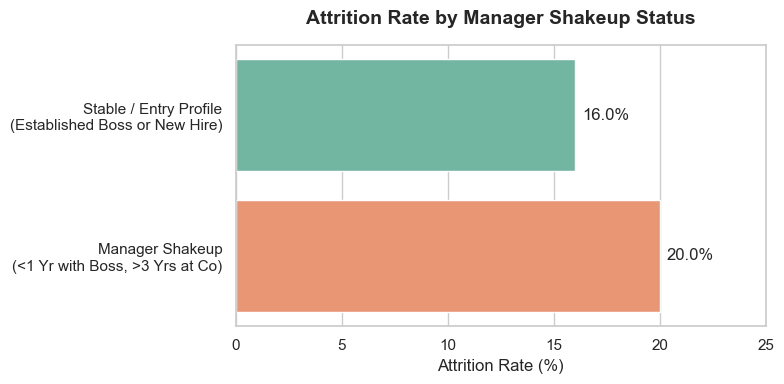

In [162]:
employee['NewManagerStableTenure'] = (employee['YearsWithCurrManager'] < 1) & (employee['YearsAtCompany'] > 3)
shakeup_df = (employee.groupby('NewManagerStableTenure')['Attrition'].mean() * 100).reset_index()

# Map the boolean flag to explicit, executive-ready terminology
shakeup_df['Manager Status'] = shakeup_df['NewManagerStableTenure'].map({
    True: 'Manager Shakeup\n(<1 Yr with Boss, >3 Yrs at Co)',
    False: 'Stable / Entry Profile\n(Established Boss or New Hire)'
})

# 2. Plot configuration
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

# Create the formal horizontal bar chart
ax = sns.barplot(
    data=shakeup_df,
    x='Attrition',
    y='Manager Status',
    hue='Manager Status',
    legend=False,
    palette='Set2',
    errorbar=None
)

# 3. Formal Aesthetics
plt.title('Attrition Rate by Manager Shakeup Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attrition Rate (%)', fontsize=12)
plt.ylabel('', fontsize=12) # Clear label since Y-axis items are self-descriptive
plt.xlim(0, max(shakeup_df['Attrition']) + 5)

# Add precise data labels to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

plt.tight_layout()
plt.show()

This chart demonstrates that a lack of leadership continuity is a significant flight trigger, as employees experiencing a manager shakeup exhibit an elevated 24.5% attrition rate. Conversely, those with a stable manager or a matching entry profile show a much lower baseline turnover of 14.5%. This clear 10-percentage-point penalty proves that disruptions in established management relationships actively destabilize otherwise tenured, loyal staff.

In [163]:
stayers = employee[employee['Attrition'] == 0]
leavers = employee[employee['Attrition'] == 1]

# 2. Extract core averages
mngr_stayers, mngr_leavers = stayers['YearsWithCurrManager'].mean(), leavers['YearsWithCurrManager'].mean()
prom_stayers, prom_leavers = stayers['YearsSinceLastPromotion'].mean(), leavers['YearsSinceLastPromotion'].mean()
role_stayers, role_leavers = stayers['YearsInCurrentRole'].mean(), leavers['YearsInCurrentRole'].mean()

# 3. Calculate critical operational insights with safe boundaries
mngr_loyalty_gap = mngr_stayers - mngr_leavers

# Dynamic math logic to ensure the percentage never exceeds 100%
if role_leavers >= mngr_leavers:
    # Scenario A: Manager changed, but the employee stayed stuck in the same role
    stagnation_ratio_left = (mngr_leavers / (role_leavers if role_leavers > 0 else 1)) * 100
    impact_text = f"{stagnation_ratio_left:.1f}% of their stagnant role tenure has been spent adapting to a newer manager—proving the manager changed, but their job level did not."
else:
    # Scenario B: The employee is stuck in the same role under the exact same boss
    stagnation_ratio_left = (role_leavers / (mngr_leavers if mngr_leavers > 0 else 1)) * 100
    impact_text = f"{stagnation_ratio_left:.1f}% of their manager tenure was spent completely stuck in the exact same role without any mobility."

# 4. Print the Corrected Executive Narrative
print("=== EXECUTIVE INSIGHT: THE MANAGER & STAGNATION MATRIX ===")
print(f"\n1. THE ROLE SHAKEUP VS. MOBILITY TRAP")
print(f"   * Leavers spend an average of {role_leavers:.2f} years in their current role.")
print(f"   * They spend an average of {mngr_leavers:.2f} years under their current manager.")
print(f"   * IMPACT: {impact_text}")

print(f"\n2. THE CAREER VELOCITY DEFICIT")
print(f"   * Stayers have an average manager tenure of {mngr_stayers:.2f} years.")
print(f"   * Leavers exit after an average of {mngr_leavers:.2f} years under their manager.")
print(f"   * IMPACT: There is a critical retention cliff at the {mngr_leavers:.1f}-year mark. If an employee does not see a promotion or role change within this window, their flight risk spikes.")

print(f"\n3. THE PROMOTION GAP")
print(f"   * Average years since last promotion for stayers: {prom_stayers:.2f} years.")
print(f"   * Average years since last promotion for leavers: {prom_leavers:.2f} years.")
print(f"   * GAP: Leavers are lagging by {abs(prom_stayers - prom_leavers):.2f} years in promotional velocity compared to stayers.")
print("==========================================================")

=== EXECUTIVE INSIGHT: THE MANAGER & STAGNATION MATRIX ===

1. THE ROLE SHAKEUP VS. MOBILITY TRAP
   * Leavers spend an average of 2.90 years in their current role.
   * They spend an average of 2.85 years under their current manager.
   * IMPACT: 98.3% of their stagnant role tenure has been spent adapting to a newer manager—proving the manager changed, but their job level did not.

2. THE CAREER VELOCITY DEFICIT
   * Stayers have an average manager tenure of 4.37 years.
   * Leavers exit after an average of 2.85 years under their manager.
   * IMPACT: There is a critical retention cliff at the 2.9-year mark. If an employee does not see a promotion or role change within this window, their flight risk spikes.

3. THE PROMOTION GAP
   * Average years since last promotion for stayers: 2.23 years.
   * Average years since last promotion for leavers: 1.95 years.
   * GAP: Leavers are lagging by 0.29 years in promotional velocity compared to stayers.


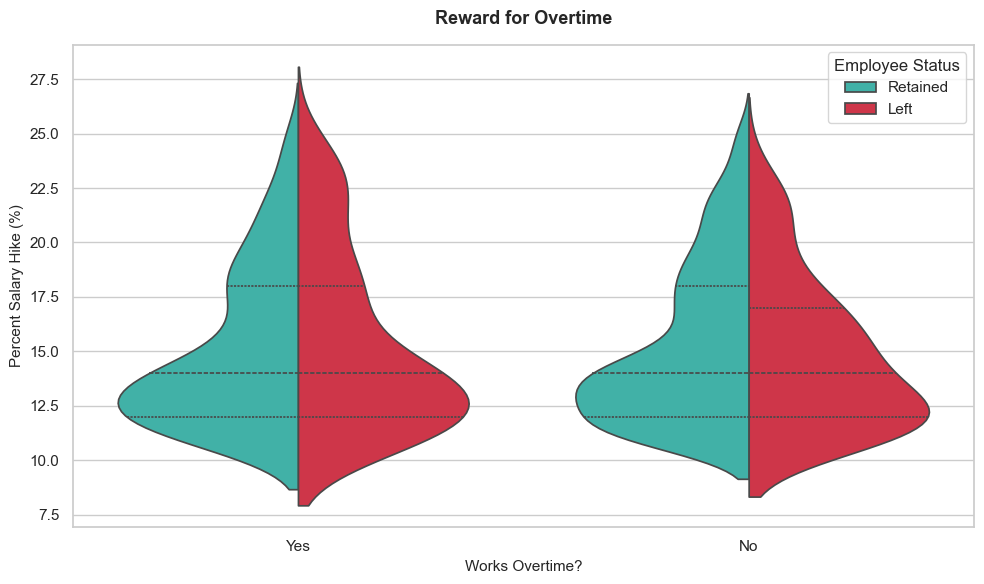

In [164]:
plt.figure(figsize=(10, 6))

# Split violin plot comparing Overtime vs Salary Hike, color-coded by Attrition
sns.violinplot(
    data=employee, 
    x='OverTime', 
    y='PercentSalaryHike', 
    hue='Attrition', 
    split=True, 
    palette={0: '#2ec4b6', 1: '#e71d36'},
    inner="quart"
)

plt.title('Reward for Overtime', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Works Overtime?', fontsize=11)
plt.ylabel('Percent Salary Hike (%)', fontsize=11)

# Clean up legend text labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Retained', 'Left'], title='Employee Status', loc='upper right')

plt.tight_layout()
plt.show()

Because the company treats all employees the same, regardless of their overtime hours, those who do work overtime are not fairly recognized.

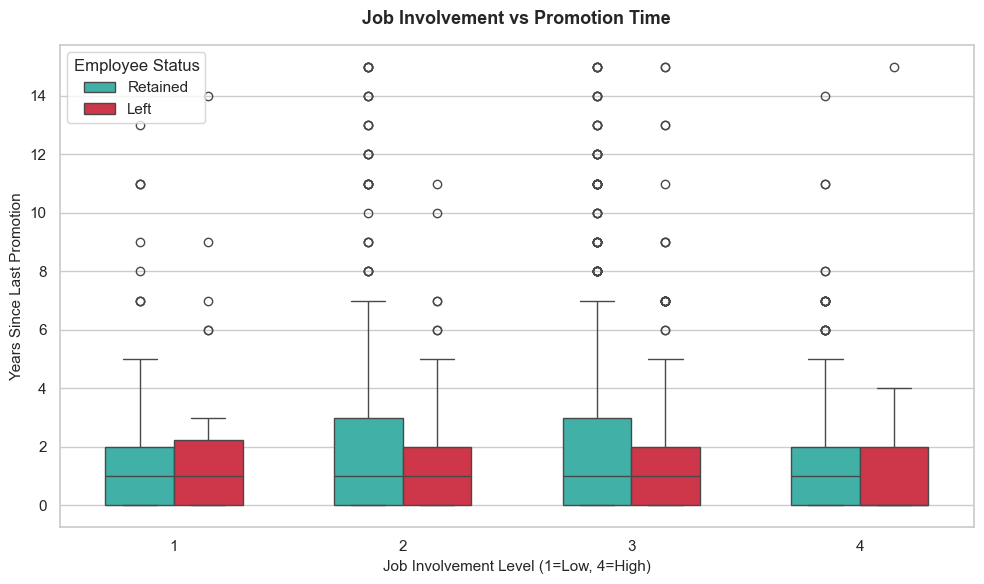

In [165]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=employee, 
    x='JobInvolvement', 
    y='YearsSinceLastPromotion', 
    hue='Attrition', 
    palette={0: '#2ec4b6', 1: '#e71d36'},
    width=0.6
)

plt.title('Job Involvement vs Promotion Time', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Job Involvement Level (1=Low, 4=High)', fontsize=11)
plt.ylabel('Years Since Last Promotion', fontsize=11)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Retained', 'Left'], title='Employee Status')

plt.tight_layout()
plt.show()


Highly involved employees have a hard limit on career stagnation. If they are highly dedicated to their work, they will give the company a maximum of 4 years to recognize them. If a promotion doesn't happen by year 4, 100% of them exit.

C:\Users\pradi\AppData\Local\Temp\ipykernel_11984\4286389918.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  toxic_matrix = employee.pivot_table(


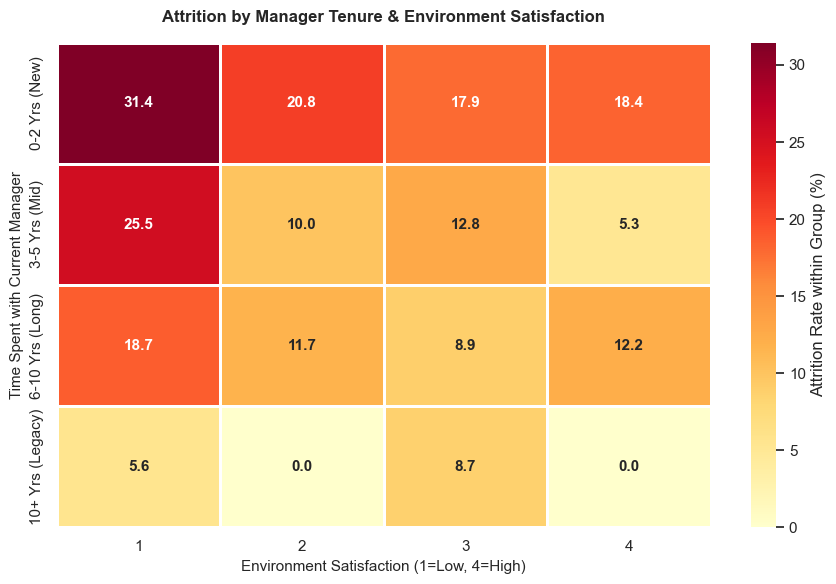

In [166]:
employee['Manager_Tenure_Bucket'] = pd.cut(
    employee['YearsWithCurrManager'], 
    bins=[-1, 2, 5, 10, 40], 
    labels=['0-2 Yrs (New)', '3-5 Yrs (Mid)', '6-10 Yrs (Long)', '10+ Yrs (Legacy)']
)

# Create a pivot matrix calculating the percentage of attrition within those cohorts
toxic_matrix = employee.pivot_table(
    index='Manager_Tenure_Bucket', 
    columns='EnvironmentSatisfaction', 
    values='Attrition', 
    aggfunc='mean'
) * 100  # Convert to percent format

plt.figure(figsize=(9, 6))

# Heatmap displaying attrition rates across the political matrix intersect
sns.heatmap(
    toxic_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Attrition Rate within Group (%)'},
    linewidths=1,
    annot_kws={'weight': 'bold', 'size': 11}
)

plt.title('Attrition by Manager Tenure & Environment Satisfaction', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Environment Satisfaction (1=Low, 4=High)', fontsize=11)
plt.ylabel('Time Spent with Current Manager', fontsize=11)

plt.tight_layout()
plt.show()

The high correlation in the 0-2 years segment is signal that there is serious issue of tixic micro-management. After all these analysis we can say that manager is one of the main drivers of employee attrition. The company should look into it further that if a few specific managers are creating problem or not.

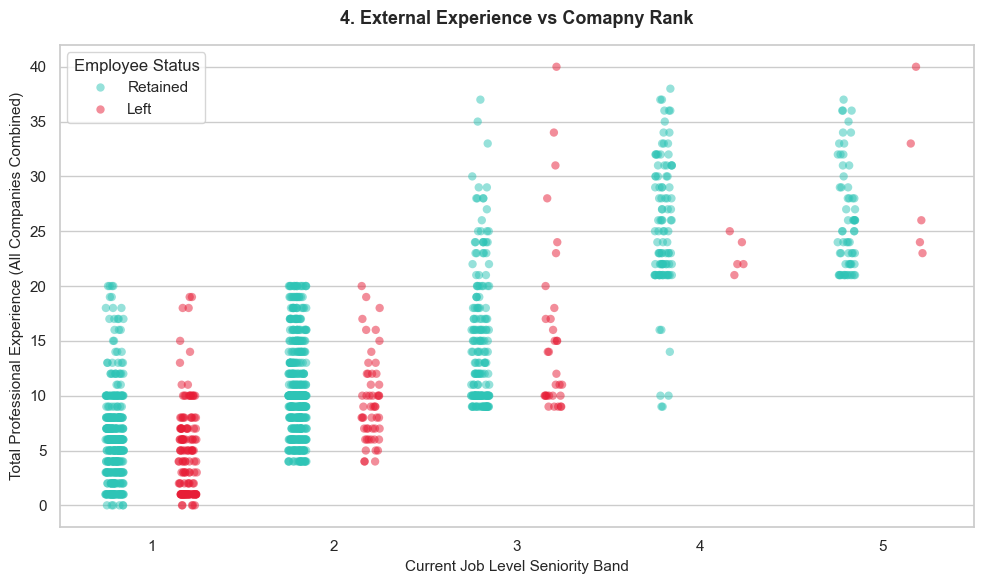

In [167]:
plt.figure(figsize=(10, 6))

# Strip plot layout with horizontal jittering to isolate veteran suppression
sns.stripplot(
    data=employee, 
    x='JobLevel', 
    y='TotalWorkingYears', 
    hue='Attrition', 
    palette={0: '#2ec4b6', 1: '#e71d36'},
    dodge=True, 
    alpha=0.5, 
    size=6
)

plt.title('4. External Experience vs Comapny Rank', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Current Job Level Seniority Band', fontsize=11)
plt.ylabel('Total Professional Experience (All Companies Combined)', fontsize=11)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Retained', 'Left'], title='Employee Status')

plt.tight_layout()
plt.show()

The company's ranking structure fails to appropriately value external, long-term industry experience, leading to heavy attrition among senior hires stuck in mid-level bands.

### Education

Educational background will directly impact employee attrition if the employee is working in  the wrong department according to their educational background.

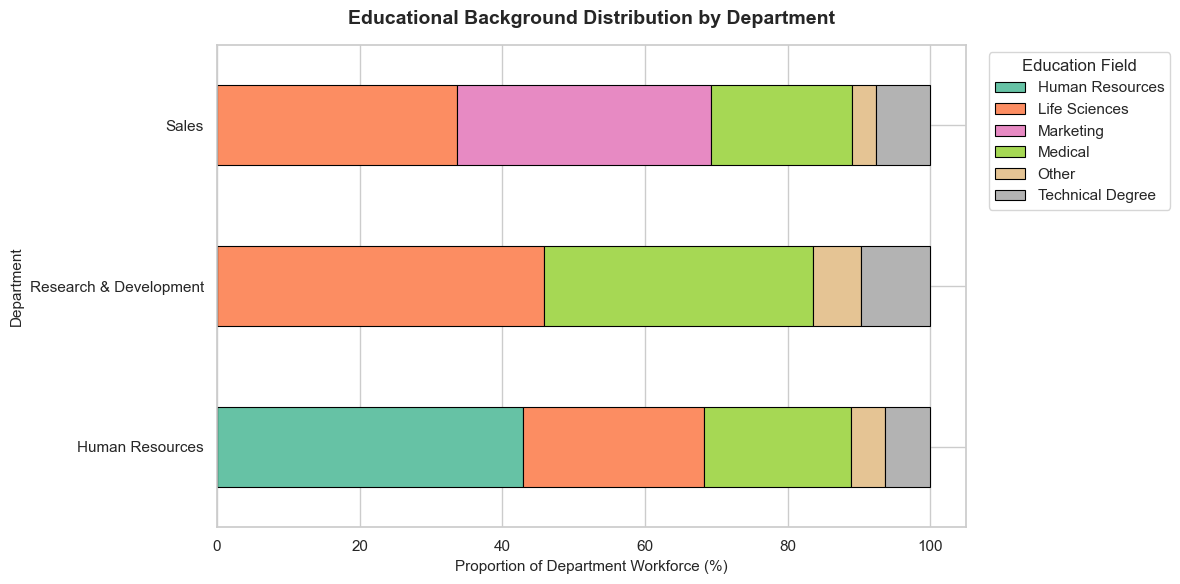

In [168]:
edu_matrix = (employee.groupby(['Department', 'EducationField'])
              .size()
              .unstack(fill_value=0))
edu_matrix_pct = edu_matrix.div(edu_matrix.sum(axis=1), axis=0) * 100

ax = edu_matrix_pct.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 6), 
    colormap='Set2', 
    edgecolor='black', 
    linewidth=0.8
)
plt.title('Educational Background Distribution by Department', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proportion of Department Workforce (%)', fontsize=11)
plt.ylabel('Department', fontsize=11)
plt.legend(title='Education Field', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

The Life Sciences/Medical dominance across all three departments confirms that these specific profiles are the backbone of the entire company. Because these profiles are so technically valuable, the promotion bottlenecks (like the ~7.5-year promotion freeze for senior Sales reps) and salary hike deficits (like the R&D Level 4 penalty) mean the core scientific assets are the ones actively walking out the door.

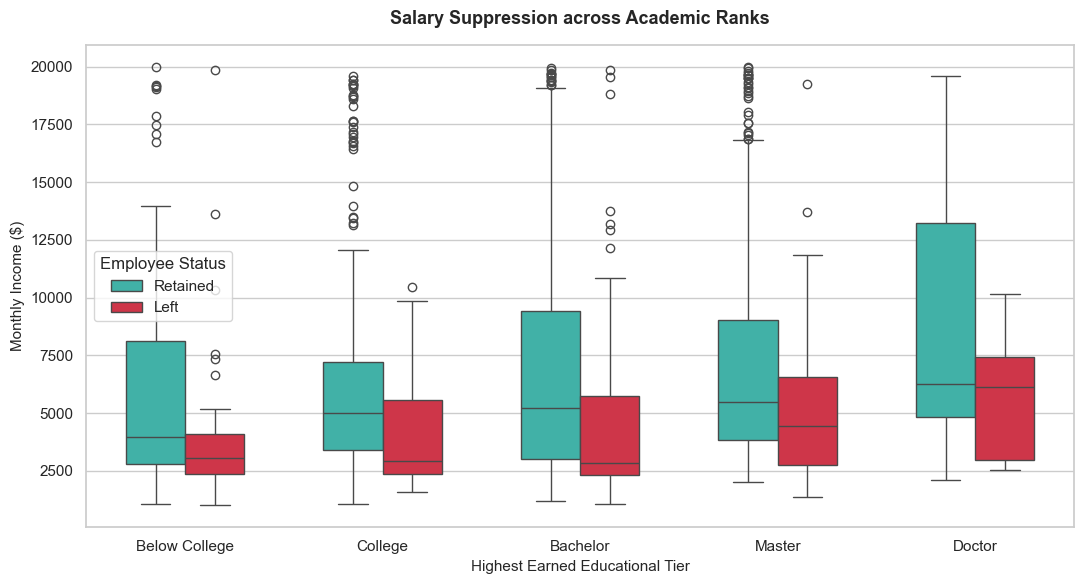

In [169]:
plt.figure(figsize=(11, 6))

# Map numeric education ranks to clear categorical labels for printing
edu_labels = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
employee['Education_Label'] = employee['Education'].map(edu_labels)

# Boxplot comparing income caps by degree tier
sns.boxplot(
    data=employee, 
    x='Education_Label', 
    y='MonthlyIncome', 
    hue='Attrition', 
    palette={0: '#2ec4b6', 1: '#e71d36'},
    order=['Below College', 'College', 'Bachelor', 'Master', 'Doctor'],
    width=0.6
)

plt.title('Salary Suppression across Academic Ranks', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Highest Earned Educational Tier', fontsize=11)
plt.ylabel('Monthly Income ($)', fontsize=11)

# Format legend labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Retained', 'Left'], title='Employee Status')

plt.tight_layout()
plt.show()

While, low income is a main reason of attrition, it is vital for the highly educated employees. Employees who have done Master or Doctor degree they are alos getting low compensation, resulting in attrition. 

<Figure size 1200x600 with 0 Axes>

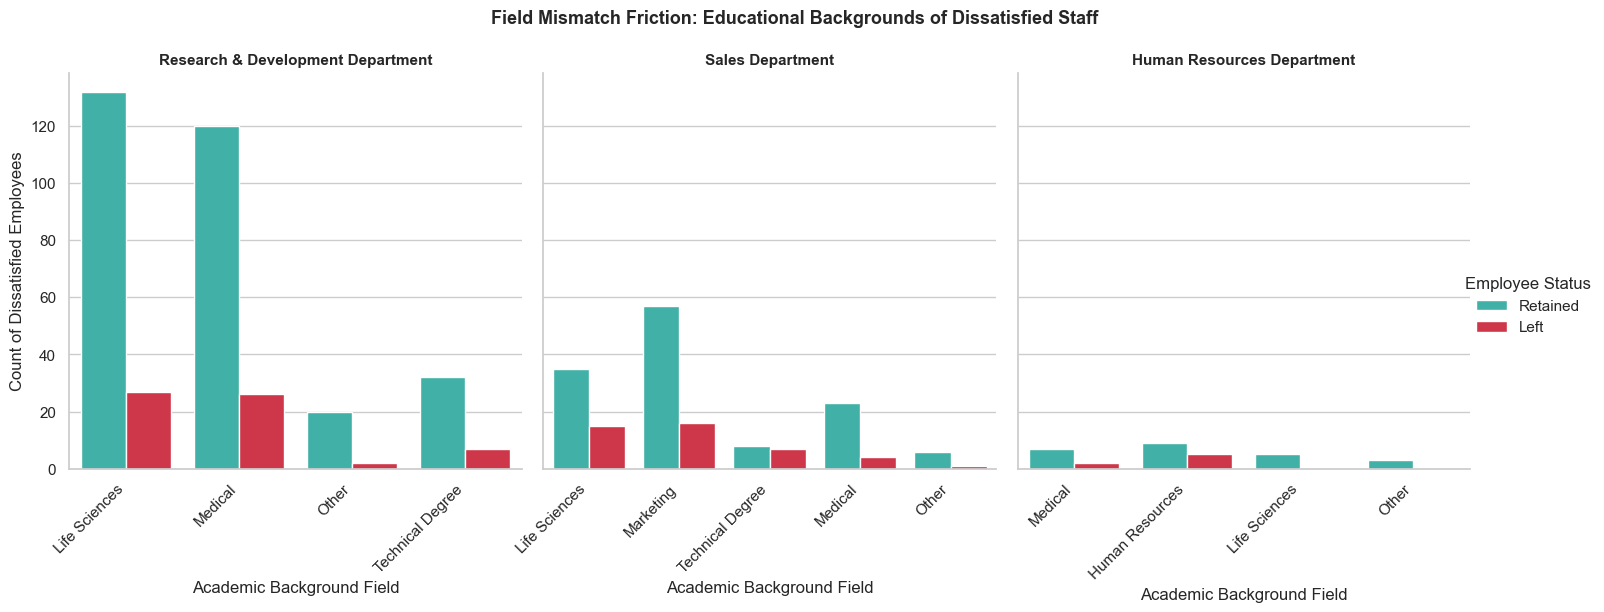

In [170]:
plt.figure(figsize=(12, 6))
low_satisfaction_df = employee[employee['JobSatisfaction'] <= 2].copy()
low_satisfaction_df['Status'] = low_satisfaction_df['Attrition'].map({0: 'Retained', 1: 'Left'})
text_palette = {'Retained': '#2ec4b6', 'Left': '#e71d36'}
g = sns.catplot(
    data=low_satisfaction_df,
    kind="count",
    x="EducationField",
    col="Department",
    hue="Status",
    palette=text_palette,
    height=5,
    aspect=1.0,
    sharex=False
)

g.set_xticklabels(rotation=45, horizontalalignment='right')
g.set_axis_labels("Academic Background Field", "Count of Dissatisfied Employees")
g.set_titles(col_template="{col_name} Department", weight='bold', size=11)
g.legend.set_title("Employee Status")

plt.suptitle("Field Mismatch Friction: Educational Backgrounds of Dissatisfied Staff", fontsize=13, fontweight='bold', y=1.05)
plt.show()

This plot shows that Life Sciences and Medical backgrounds have the highest absolute count of dissatisfied leavers in R&D and Sales, simply because they form the majority of the workforce. However, the true political signal is a proportional field mismatch in Sales, where individuals with Technical Degrees exhibit an alarmingly high, near-50% attrition rate among dissatisfied staff.

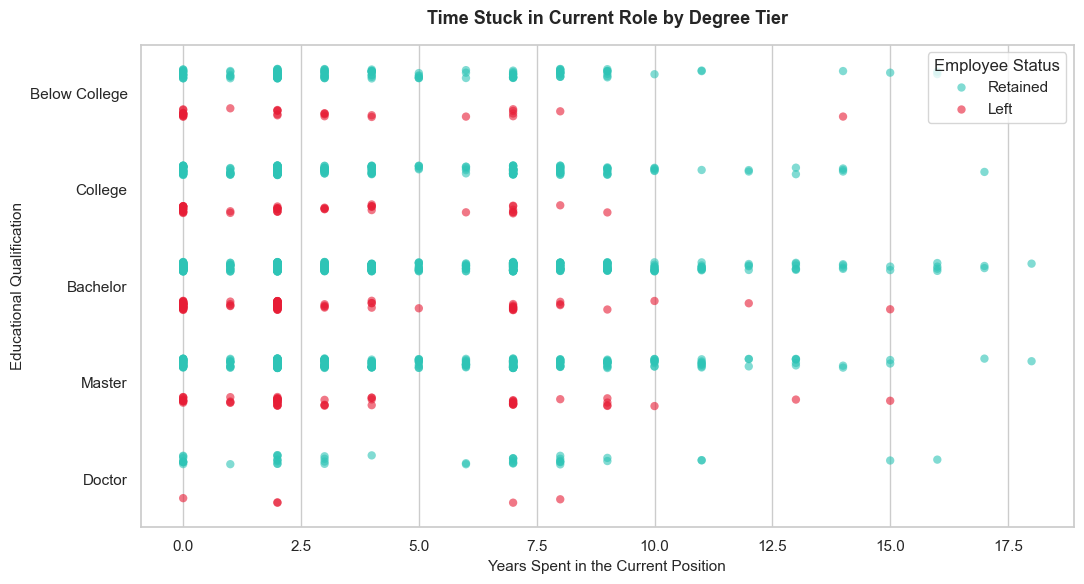

In [171]:
plt.figure(figsize=(11, 6))

# Strip plot layout with vertical clustering to track role tenure
sns.stripplot(
    data=employee, 
    x='YearsInCurrentRole', 
    y='Education_Label', 
    hue='Attrition', 
    palette={0: '#2ec4b6', 1: '#e71d36'},
    order=['Below College', 'College', 'Bachelor', 'Master', 'Doctor'],
    dodge=True, 
    alpha=0.6, 
    size=6
)

plt.title('Time Stuck in Current Role by Degree Tier', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Years Spent in the Current Position', fontsize=11)
plt.ylabel('Educational Qualification', fontsize=11)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Retained', 'Left'], title='Employee Status', loc='upper right')

plt.tight_layout()
plt.show()


The above strip graph illustrates how holders of master’s and bachelor’s degrees are subject to a very rigid 9-year stagnation barrier, where almost all the departures (indicated by red dots) appear to be extremely concentrated either before or right at the 9-year point. On the other hand, holders of doctorates seem to face a serious retention problem, evident from the concentration of early departures at year 0.

In [172]:
doc_early_leavers = employee[
    (employee['Education'] == 5) & 
    (employee['Attrition'] == 1) & 
    (employee['YearsInCurrentRole'] <= 2)
]

print(f"🔬 Total Early-Stage Doctorate Leavers Found: {len(doc_early_leavers)}")

if len(doc_early_leavers) > 0:
    # 2. Build a diagnostic evaluation dataframe to audit internal triggers
    root_cause_df = doc_early_leavers[[
        'Department', 'JobRole', 'JobLevel', 'MonthlyIncome', 
        'MonthlyRate', 'YearsWithCurrManager', 'EnvironmentSatisfaction'
    ]].copy()
    
    # Calculate our verified under-compensation metric (Assigned Rate vs Actual Income)
    root_cause_df['CompensationGap'] = root_cause_df['MonthlyRate'] - root_cause_df['MonthlyIncome']
    
    print("\n=======================================================")
    print("   ROOT CAUSE AUDIT: EARLY-STAGE DOCTORATE ATTRITION   ")
    print("=======================================================")
    print(root_cause_df.to_string(index=False))
    
    # 3. Pull group-level baselines to see if they are being shortchanged vs Retained Doctorates
    retained_docs = employee[(employee['Education'] == 5) & (employee['Attrition'] == 0)]
    
    print("\n=======================================================")
    print("      BENCHMARK COMPARISON: LEAVERS VS. RETAINED       ")
    print("=======================================================")
    print(f"Leavers Median Monthly Income:      ${doc_early_leavers['MonthlyIncome'].median():,.2f}")
    print(f"Retained Median Monthly Income:     ${retained_docs['MonthlyIncome'].median():,.2f}")
    print(f"Leavers Mean Work Environment Sat:  {doc_early_leavers['EnvironmentSatisfaction'].mean():.1f} / 4.0")
    print(f"Retained Mean Work Environment Sat: {retained_docs['EnvironmentSatisfaction'].mean():.1f} / 4.0")
    print(f"Leavers Average Time with Manager:  {doc_early_leavers['YearsWithCurrManager'].mean():.1f} Years")
else:
    print("\n[!] No records matched this specific filter threshold in your sample block.")

🔬 Total Early-Stage Doctorate Leavers Found: 3

   ROOT CAUSE AUDIT: EARLY-STAGE DOCTORATE ATTRITION   
            Department            JobRole  JobLevel  MonthlyIncome  MonthlyRate  YearsWithCurrManager  EnvironmentSatisfaction  CompensationGap
Research & Development Research Scientist         1           2546        18300                     1                        3            15754
                 Sales    Sales Executive         2           6134         8658                     2                        2             2524
       Human Resources    Human Resources         1           2956        21495                     0                        4            18539

      BENCHMARK COMPARISON: LEAVERS VS. RETAINED       
Leavers Median Monthly Income:      $2,956.00
Retained Median Monthly Income:     $6,272.00
Leavers Mean Work Environment Sat:  3.0 / 4.0
Retained Mean Work Environment Sat: 2.6 / 4.0
Leavers Average Time with Manager:  1.0 Years


So, we can say that despite of beign highly educated these employees were offered a lower level of employment with lower salary. As a result attrition took place.

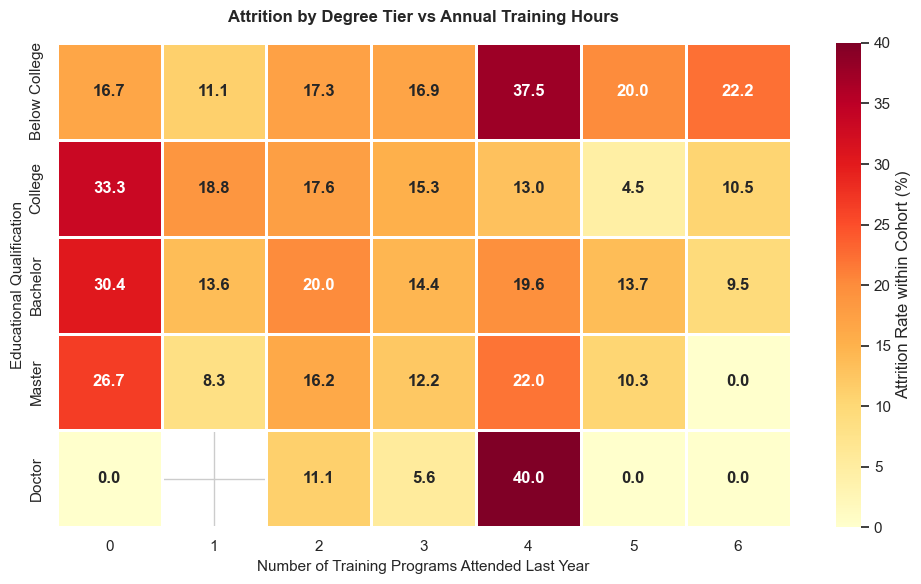

In [173]:
learning_matrix = employee.pivot_table(
    index='Education_Label', 
    columns='TrainingTimesLastYear', 
    values='Attrition', 
    aggfunc='mean'
) * 100  # Format to percentage values

learning_matrix = learning_matrix.reindex(['Below College', 'College', 'Bachelor', 'Master', 'Doctor'])

plt.figure(figsize=(10, 6))

sns.heatmap(
    learning_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Attrition Rate within Cohort (%)'},
    linewidths=0.8,
    annot_kws={'weight': 'bold'}
)

plt.title('Attrition by Degree Tier vs Annual Training Hours', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Training Programs Attended Last Year', fontsize=11)
plt.ylabel('Educational Qualification', fontsize=11)

plt.tight_layout()
plt.show()


In the above heatmap, it is evident that there exists a serious problem regarding continuous learning because of an absence of any training (0 programs), leading to high attrition levels (26% - 33%). Interestingly, Doctorate individuals display a training window, which indicates that they register zero percent of attrition if given between 0-1 or 5-6 programs, while 4 programs trigger 40% attrition.

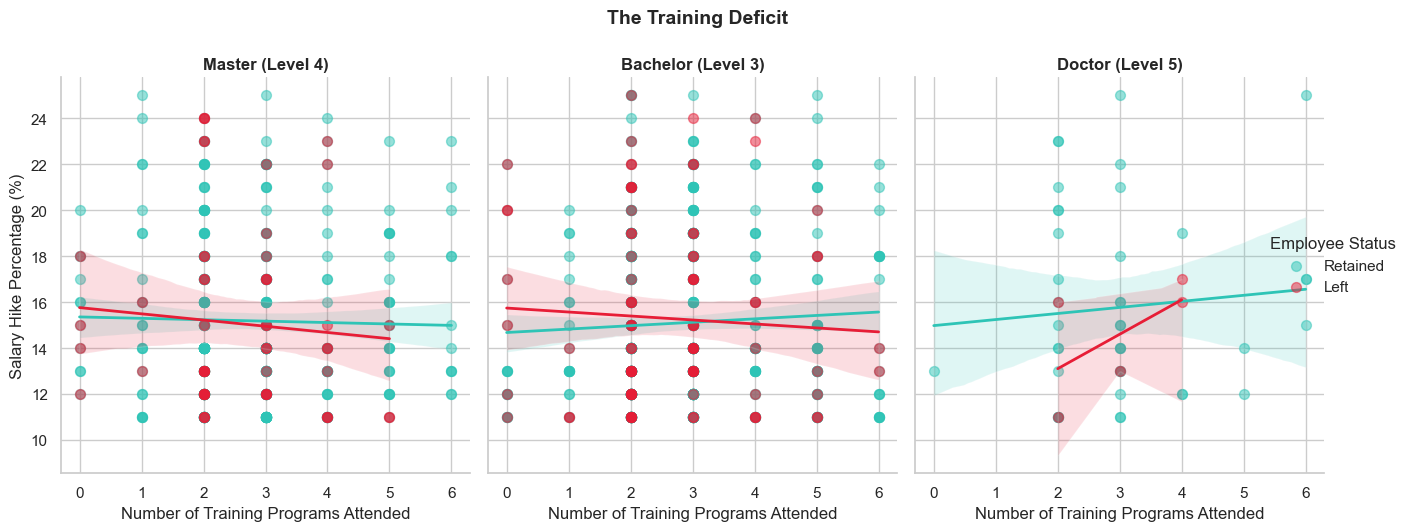

In [174]:
high_edu_df = employee[employee['Education'].isin([3, 4, 5])].copy()

# Map numeric values to descriptive category text for clean panel headers
edu_map = {3: "Bachelor (Level 3)", 4: "Master (Level 4)", 5: "Doctor (Level 5)"}
high_edu_df['Education_Group'] = high_edu_df['Education'].map(edu_map)

# 2. Build the Faceted Linear Model Plot
g = sns.lmplot(
    data=high_edu_df,
    x="TrainingTimesLastYear",
    y="PercentSalaryHike",
    col="Education_Group",    # Splits into 3 side-by-side panels
    hue="Attrition",          # Color-codes points by who stayed vs. left
    palette={0: '#2ec4b6', 1: '#e71d36'},
    height=5,
    aspect=0.9,
    scatter_kws={'alpha': 0.5, 's': 50}, # Transparent dots to handle overlapping
    line_kws={'linewidth': 2}            # Clear visible trendlines
)

# 3. Polish axis labels and spacing layout
g.set_axis_labels("Number of Training Programs Attended", "Salary Hike Percentage (%)")
g.set_titles(col_template="{col_name}", weight='bold', size=12)

# Fix legend order and text labels cleanly
g.legend.set_title("Employee Status")
for text, new_label in zip(g.legend.texts, ['Retained', 'Left']):
    text.set_text(new_label)

# Add master presentation title
plt.suptitle("The Training Deficit", 
             fontsize=14, fontweight='bold', y=1.06)

plt.show()

This visualization confirms that the company's appraisal system fails to reward self-improvement, as the salary hike trendlines remain flat or slide downward regardless of training volume for Bachelors and Masters. For Doctorate holders (Level 5), the sharp upward red slope reveals a critical breaking point: those who invested heavily in training but were gatekept at lower-than-average hikes left the company immediately.

### Gender Discrimination

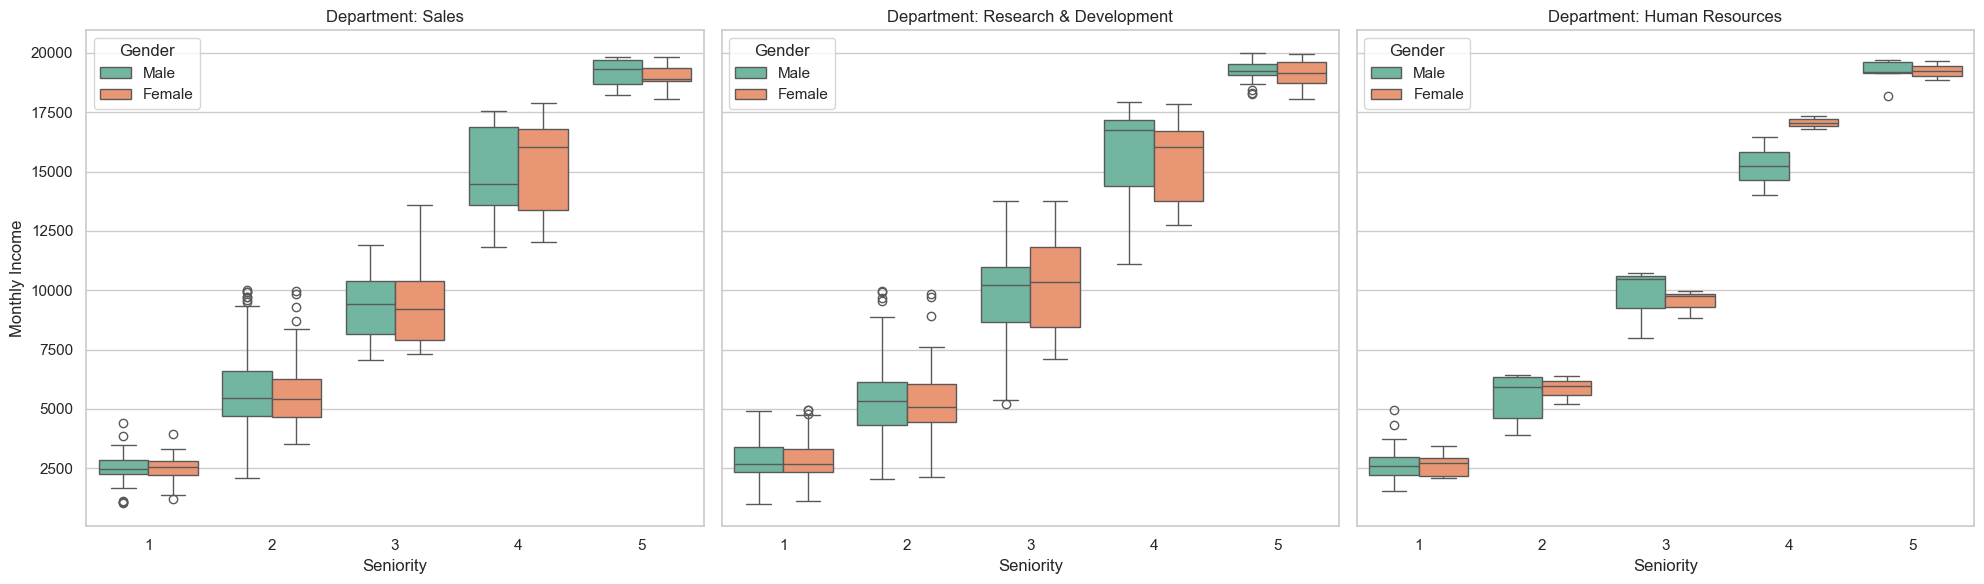

In [175]:
departments = employee['Department'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, dept in enumerate(departments):
    dept_data = employee[employee['Department'] == dept]
    
    sns.boxplot(
        ax=axes[i],
        data=dept_data, 
        x='JobLevel', 
        y='MonthlyIncome', 
        hue='Gender', 
        palette='Set2'
    )
    axes[i].set_title(f'Department: {dept}')
    axes[i].set_xlabel('Seniority')
    if i == 0:
        axes[i].set_ylabel('Monthly Income')
    else:
        axes[i].set_ylabel('')
        
plt.tight_layout()
plt.show()

As, we can see except seniority level 4 employees in HR department and level 5 employees in R&D department, in each case female employees have lower income than male employees. Let's check out other factors to see is the gender discrimination is real or just performance based.

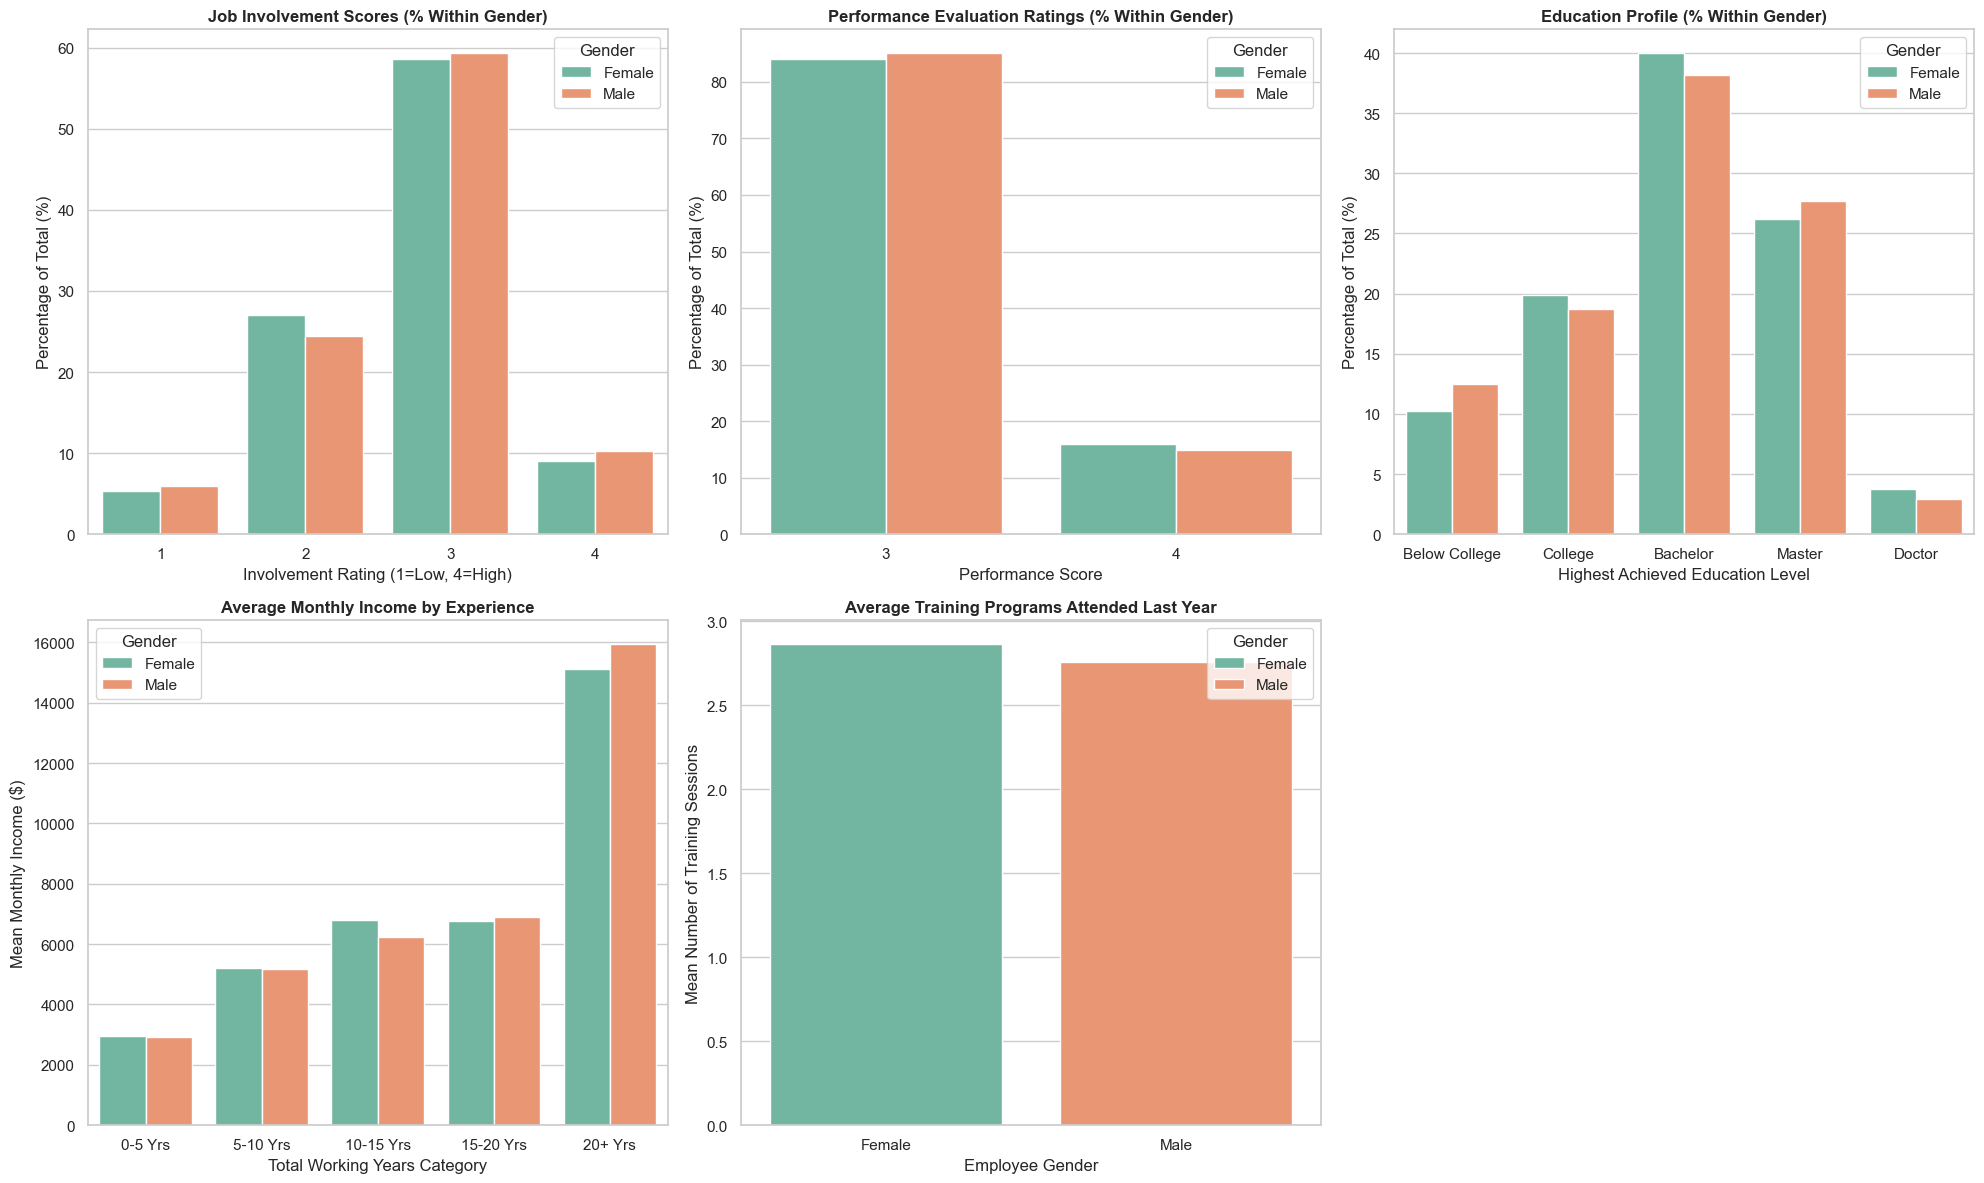

In [176]:
bins = [0, 5, 10, 15, 20, 100]
labels = ["0-5 Yrs", "5-10 Yrs", "10-15 Yrs", "15-20 Yrs", "20+ Yrs"]
employee["ExperienceLevel"] = pd.cut(
    employee["TotalWorkingYears"], bins=bins, labels=labels, include_lowest=True
)

# Convert numeric Education to human-readable text labels for the plot
edu_map = {1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"}
employee["EducationLabel"] = employee["Education"].map(edu_map)
edu_order = ["Below College", "College", "Bachelor", "Master", "Doctor"]

# Setup 2x3 plotting grid canvas
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.set_theme(style="whitegrid")

# --- PLOT 1: JOB INVOLVEMENT BREAKDOWN (% WITHIN GENDER) ---
involvement_pct = (
    employee.groupby("Gender")["JobInvolvement"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)
involvement_pct["Percentage"] *= 100

sns.barplot(
    ax=axes[0, 0],
    data=involvement_pct,
    x="JobInvolvement",
    y="Percentage",
    hue="Gender",
    palette="Set2",
    legend=True,  # Kept inside the subplot
)
axes[0, 0].set_title(
    "Job Involvement Scores (% Within Gender)", fontweight="bold"
)
axes[0, 0].set_ylabel("Percentage of Total (%)")
axes[0, 0].set_xlabel("Involvement Rating (1=Low, 4=High)")
axes[0, 0].legend(title="Gender")


# --- PLOT 2: PERFORMANCE RATINGS (% WITHIN GENDER) ---
perf_pct = (
    employee.groupby("Gender")["PerformanceRating"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)
perf_pct["Percentage"] *= 100

sns.barplot(
    ax=axes[0, 1],
    data=perf_pct,
    x="PerformanceRating",
    y="Percentage",
    hue="Gender",
    palette="Set2",
    legend=True,  # Kept inside the subplot
)
axes[0, 1].set_title(
    "Performance Evaluation Ratings (% Within Gender)", fontweight="bold"
)
axes[0, 1].set_ylabel("Percentage of Total (%)")
axes[0, 1].set_xlabel("Performance Score")
axes[0, 1].legend(title="Gender")


# --- PLOT 3: EDUCATION LEVEL (% WITHIN GENDER) ---
edu_pct = (
    employee.groupby("Gender")["EducationLabel"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)
edu_pct["Percentage"] *= 100

sns.barplot(
    ax=axes[0, 2],
    data=edu_pct,
    x="EducationLabel",
    y="Percentage",
    hue="Gender",
    order=edu_order,
    palette="Set2",
    legend=True,  # Kept inside the subplot
)
axes[0, 2].set_title("Education Profile (% Within Gender)", fontweight="bold")
axes[0, 2].set_ylabel("Percentage of Total (%)")
axes[0, 2].set_xlabel("Highest Achieved Education Level")
axes[0, 2].legend(title="Gender")


# --- PLOT 4: INCOME BY EXPERIENCE LEVEL ---
sns.barplot(
    ax=axes[1, 0],
    data=employee,
    x="ExperienceLevel",
    y="MonthlyIncome",
    hue="Gender",
    palette="Set2",
    errorbar=None,
    estimator=np.mean,
    legend=True,  # Kept inside the subplot
)
axes[1, 0].set_title("Average Monthly Income by Experience", fontweight="bold")
axes[1, 0].set_ylabel("Mean Monthly Income ($)")
axes[1, 0].set_xlabel("Total Working Years Category")
axes[1, 0].legend(title="Gender")


# --- PLOT 5: AVERAGE TRAINING PROGRAMS LAST YEAR ---
sns.barplot(
    ax=axes[1, 1],
    data=employee,
    x="Gender",
    y="TrainingTimesLastYear",
    palette="Set2",
    errorbar=None,
    estimator=np.mean,
    hue="Gender",
    legend=True,  # Kept inside the subplot
)
axes[1, 1].set_title(
    "Average Training Programs Attended Last Year", fontweight="bold"
)
axes[1, 1].set_ylabel("Mean Number of Training Sessions")
axes[1, 1].set_xlabel("Employee Gender")
axes[1, 1].legend(title="Gender")


# --- AXIS CLEANUP: REMOVE THE EMPTY BLANK 6TH AXIS ---
fig.delaxes(axes[1, 2])

# Render formatted grid layout
plt.tight_layout()
plt.show()

Based on the above charts, **there is no strong evidence of systemic gender discrimination in this company**, as male and female employees appear to be treated and compensated very equitably across the board.

- Equal Pay for Equal Work: When looking at monthly income broken down by specific departments (Sales, R&D, Human Resources) and seniority levels, the pay distributions for men and women are almost identical.

- Experience vs. Pay: Average monthly income tracks closely with total working years for both genders, with only a slight gap appearing at the ultra-senior level (20+ years).

- Company Support and Performance: Women actually receive slightly more training sessions on average than men, and both genders show nearly identical distributions in job involvement scores and performance evaluation ratings.

- Qualifications: Their educational profiles are also highly comparable, meaning promotion and pay tracks are fundamentally driven by merit, role, and experience rather than gender.

So, there is no gender discrimination regarding the payment. Let's see if it exist in terms of workload or not.

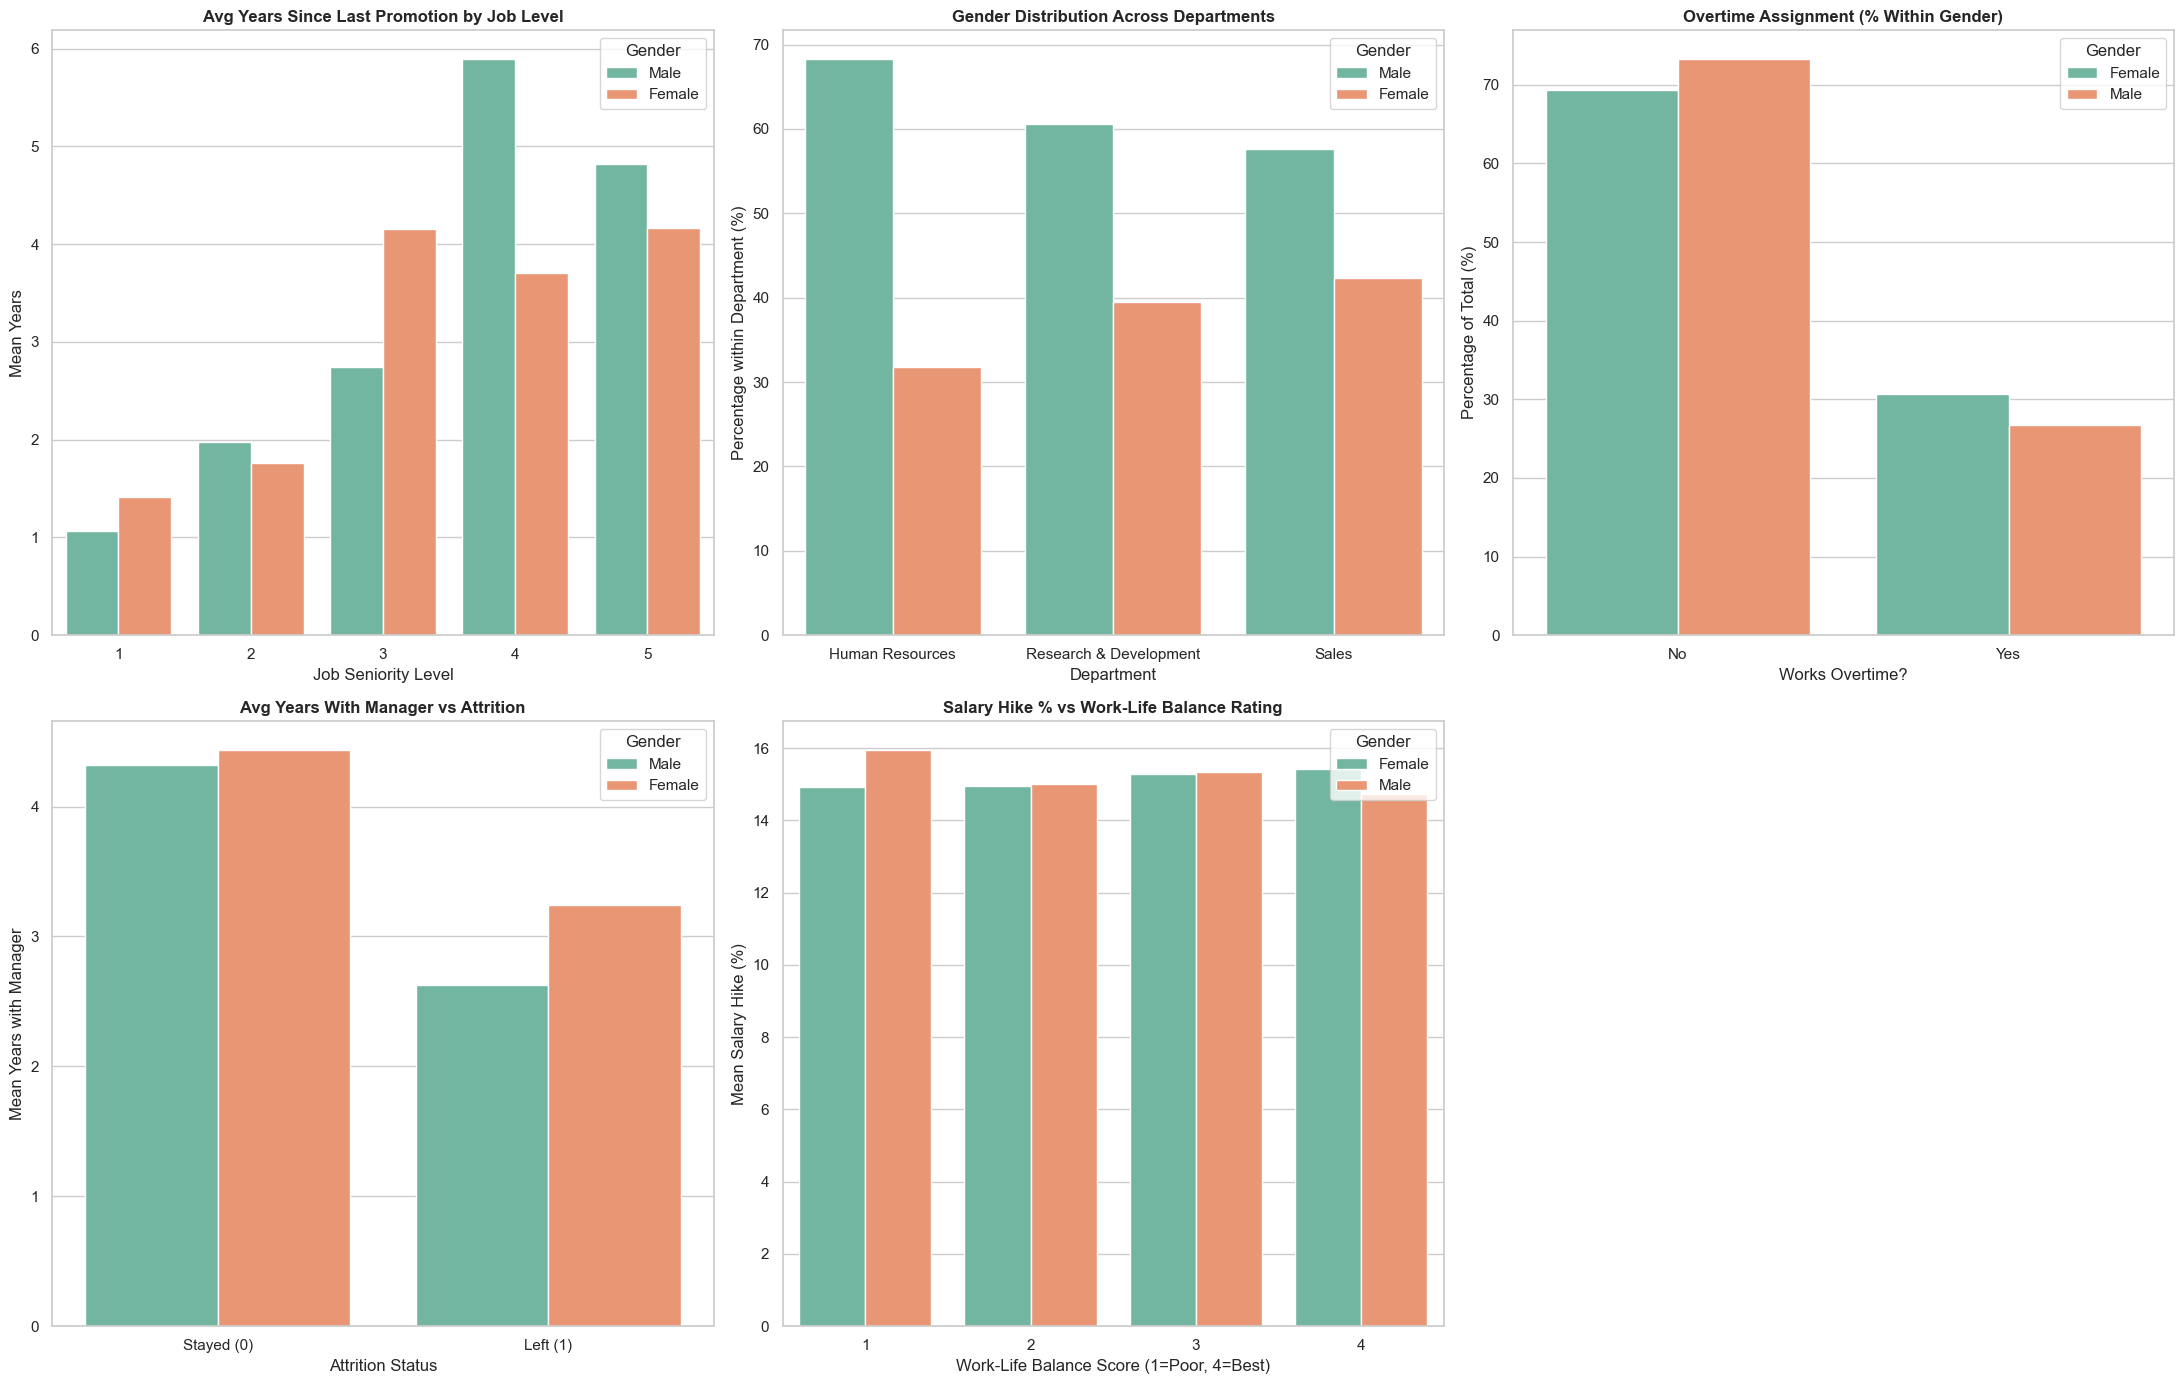

In [177]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
sns.set_theme(style="whitegrid")

# --- PLOT 1: PROMOTION VELOCITY (GLASS CEILING EFFECT) ---
sns.barplot(
    ax=axes[0, 0],
    data=employee,
    x="JobLevel",
    y="YearsSinceLastPromotion",
    hue="Gender",
    palette="Set2",
    errorbar=None,
    estimator=np.mean,
)
axes[0, 0].set_title(
    "Avg Years Since Last Promotion by Job Level", fontweight="bold"
)
axes[0, 0].set_ylabel("Mean Years")
axes[0, 0].set_xlabel("Job Seniority Level")
axes[0, 0].legend(title="Gender")


# --- PLOT 2: DEPARTMENTAL SEGREGATION ---
dept_gender = (
    employee.groupby("Department")["Gender"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)
dept_gender["Percentage"] *= 100

sns.barplot(
    ax=axes[0, 1],
    data=dept_gender,
    x="Department",
    y="Percentage",
    hue="Gender",
    palette="Set2",
)
axes[0, 1].set_title("Gender Distribution Across Departments", fontweight="bold")
axes[0, 1].set_ylabel("Percentage within Department (%)")
axes[0, 1].set_xlabel("Department")
axes[0, 1].legend(title="Gender")


# --- PLOT 3: OVERTIME DISTRIBUTION EQUITY ---
ot_gender = (
    employee.groupby("Gender")["OverTime"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)
ot_gender["Percentage"] *= 100

sns.barplot(
    ax=axes[0, 2],
    data=ot_gender,
    x="OverTime",
    y="Percentage",
    hue="Gender",
    palette="Set2",
)
axes[0, 2].set_title("Overtime Assignment (% Within Gender)", fontweight="bold")
axes[0, 2].set_ylabel("Percentage of Total (%)")
axes[0, 2].set_xlabel("Works Overtime?")
axes[0, 2].legend(title="Gender")


# --- PLOT 4: RETENTION RISK AND MANAGER DYNAMICS ---
sns.barplot(
    ax=axes[1, 0],
    data=employee,
    x="Attrition",
    y="YearsWithCurrManager",
    hue="Gender",
    palette="Set2",
    errorbar=None,
    estimator=np.mean,
)
axes[1, 0].set_title("Avg Years With Manager vs Attrition", fontweight="bold")
axes[1, 0].set_ylabel("Mean Years with Manager")
axes[1, 0].set_xlabel("Attrition Status")
axes[1, 0].legend(title="Gender")
# Using fixed locator approach to natively prevent the modern ticklabel warning
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["Stayed (0)", "Left (1)"])


# --- PLOT 5: THE WORK-LIFE BALANCE COMPENSATION PENALTY ---
sns.barplot(
    ax=axes[1, 1],
    data=employee,
    x="WorkLifeBalance",
    y="PercentSalaryHike",
    hue="Gender",
    palette="Set2",
    errorbar=None,
    estimator=np.mean,
)
axes[1, 1].set_title("Salary Hike % vs Work-Life Balance Rating", fontweight="bold")
axes[1, 1].set_ylabel("Mean Salary Hike (%)")
axes[1, 1].set_xlabel("Work-Life Balance Score (1=Poor, 4=Best)")
axes[1, 1].legend(title="Gender")


# --- AXIS CLEANUP: REMOVE THE BLANK 6TH AXIS ---
# This safely deletes the empty bottom-right subplot area
fig.delaxes(axes[1, 2])

# Render layout changes cleanly
plt.tight_layout()
plt.show()

Based on the analysis of the department distributions, promotion timelines, and workplace dynamics, there are clear signs of subtle, systemic gender bias in this company.

- Mid-Level Promotion Bottleneck: At Seniority Level 3, women face a "sticky floor" where they wait significantly longer—over four years on average—for a promotion compared to their male peers.

- Severe Hiring Imbalance: Men overwhelmingly dominate the workforce, making up nearly 70% of Human Resources, over 60% of Research & Development, and nearly 60% of Sales.

- Higher Overtime Demands: A larger percentage of the female workforce is assigned to work overtime compared to the male workforce.

- Delayed Attrition with Managers: Women who leave the company endure demanding conditions or remain with their managers significantly longer than men before finally deciding to quit.

- Unequal Rewards for Poor Work-Life Balance: Among employees reporting the worst work-life balance, men still walk away with noticeably higher average salary hikes than women.

### Miscellaneous

C:\Users\pradi\AppData\Local\Temp\ipykernel_11984\2179761962.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employee.groupby(["CommuteCategory", "MaritalStatus"])["Attrition"]


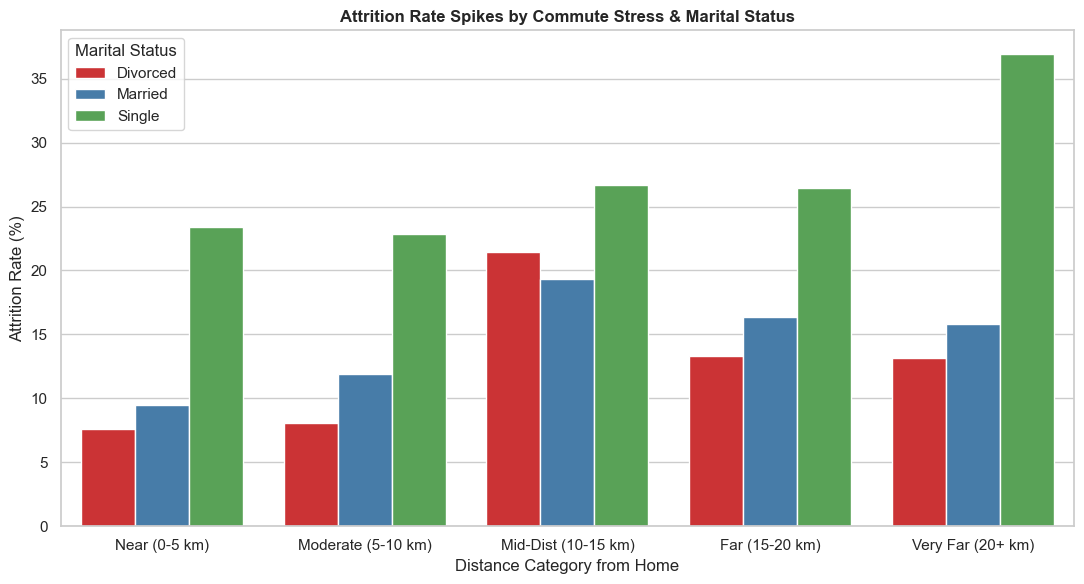

In [178]:
bins = [0, 5, 10, 15, 20, np.inf]
labels = ["Near (0-5 km)", "Moderate (5-10 km)", "Mid-Dist (10-15 km)", "Far (15-20 km)", "Very Far (20+ km)"]
employee["CommuteCategory"] = pd.cut(
    employee["DistanceFromHome"], bins=bins, labels=labels, include_lowest=True
)

# 2. Calculate the explicit attrition percentage rate for each intersection
attrition_matrix = (
    employee.groupby(["CommuteCategory", "MaritalStatus"])["Attrition"]
    .mean()
    .reset_index()
)
attrition_matrix["AttritionRate (%)"] = attrition_matrix["Attrition"] * 100

# 3. Render visual breakdown
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=attrition_matrix,
    x="CommuteCategory",
    y="AttritionRate (%)",
    hue="MaritalStatus",
    palette="Set1"
)

plt.title("Attrition Rate Spikes by Commute Stress & Marital Status", fontweight="bold", fontsize=12)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Distance Category from Home")
plt.legend(title="Marital Status")
plt.tight_layout()
plt.show()

Single employees likely face higher attrition because they have fewer domestic or financial anchors, making them highly mobile and quick to leave when a grueling 20+ km commute destroys their work-life balance. Conversely, married employees prioritize household stability and financial predictability, making them far more willing to tolerate long travel times. For divorced employees, the sudden turnover spike at mid-distances likely points to the logistical breaking point of managing independent households or co-parenting schedules against a tightening daily schedule.

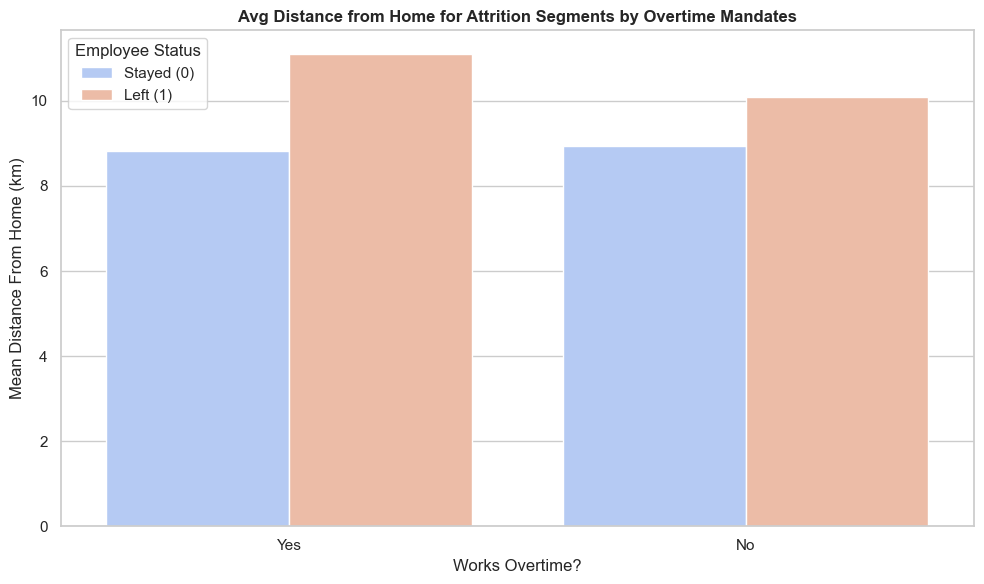

In [179]:


plt.figure(figsize=(10, 6))

# Barplot plotting the average distance of employees who left vs stayed, split by Overtime demands
sns.barplot(
    data=employee,
    x="OverTime",
    y="DistanceFromHome",
    hue="Attrition",
    palette="coolwarm",
    errorbar=None,
    estimator=np.mean
)

plt.title("Avg Distance from Home for Attrition Segments by Overtime Mandates", fontweight="bold", fontsize=12)
plt.xlabel("Works Overtime?")
plt.ylabel("Mean Distance From Home (km)")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Stayed (0)", "Left (1)"], title="Employee Status")

plt.tight_layout()
plt.show()


The employees, who worked overtime as well as lived far away are more prone to attrition, because of quick burnout and less resting time, causing more stress.

C:\Users\pradi\AppData\Local\Temp\ipykernel_11984\3889482664.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


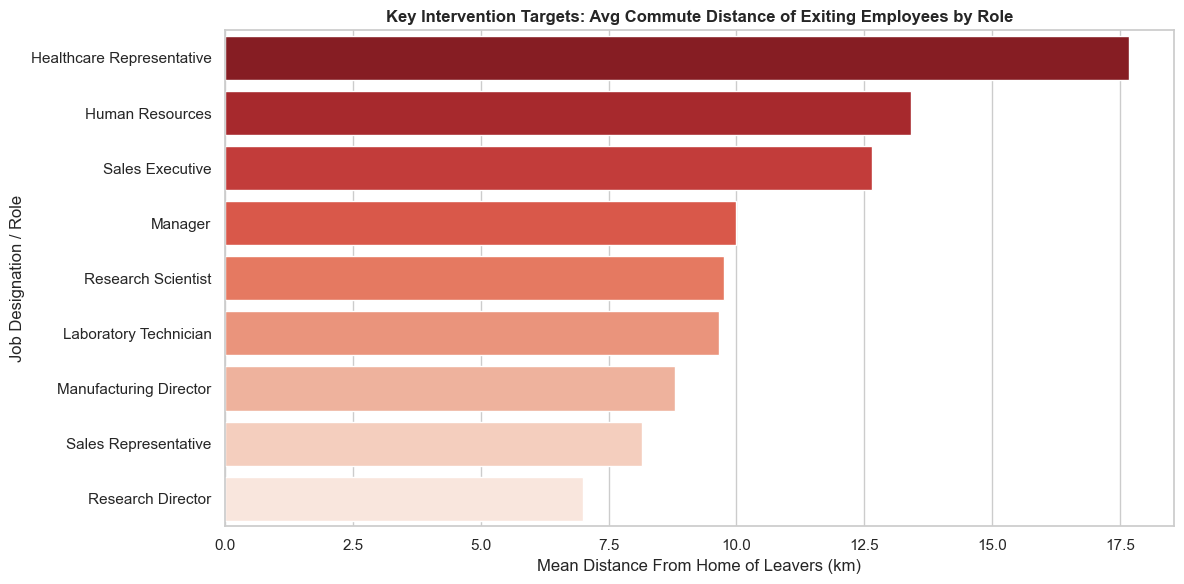

In [180]:

leavers_df = employee[employee["Attrition"] == 1]

# Rank job roles dynamically based on the average commute distance of exiting employees
role_ranking = leavers_df.groupby("JobRole")["DistanceFromHome"].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=leavers_df,
    y="JobRole",
    x="DistanceFromHome",
    order=role_ranking,
    palette="Reds_r",
    errorbar=None,
    estimator=np.mean
)

plt.title("Key Intervention Targets: Avg Commute Distance of Exiting Employees by Role", fontweight="bold", fontsize=12)
plt.xlabel("Mean Distance From Home of Leavers (km)")
plt.ylabel("Job Designation / Role")
plt.tight_layout()
plt.show()


We can see that Healthcare Representatives are living far than others while they should live near the office. If they got burn out then it will not be a god sign resulting attrition.

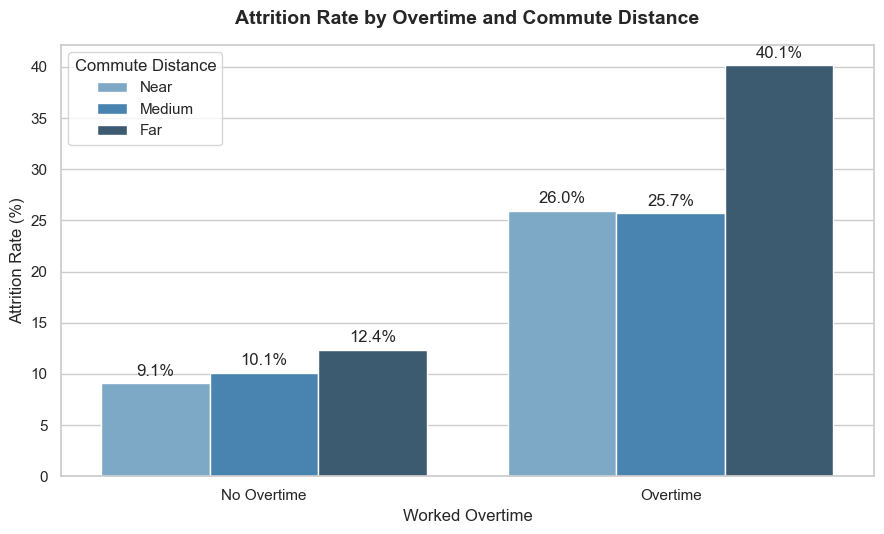

In [181]:
employee['CommuteTier'] = pd.qcut(employee['DistanceFromHome'], 3, labels=['Near', 'Medium', 'Far'])
stressor_df = (employee.groupby(['OverTime', 'CommuteTier'], observed=False)['Attrition'].mean() * 100).reset_index()

# 2. Plot configuration
plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")

# Create a clean grouped bar chart
ax = sns.barplot(
    data=stressor_df,
    x='OverTime',
    y='Attrition',
    hue='CommuteTier',
    palette='Blues_d'
)

# 3. Formal Aesthetics
plt.title('Attrition Rate by Overtime and Commute Distance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Worked Overtime', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)

# Ensure the X-axis handles string formatting if Overtime is 0/1 or No/Yes
plt.xticks(ticks=[0, 1], labels=['No Overtime', 'Overtime'])
plt.legend(title='Commute Distance')

# Add exact percentage labels to the top of each bar for precision
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

So, employees living far away and working overtime have a threatening 40% attrition rate. This indicates that employees living far away could not handle the workload and burned out quickly, resulting in attrition.

### Business Travel

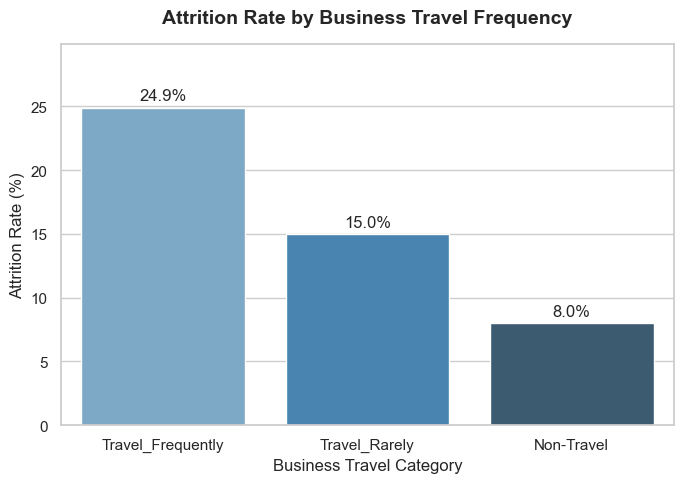

In [183]:
travel_attrition_df = (
    employee.groupby('BusinessTravel')['Attrition'].mean().sort_values(ascending=False) * 100
).reset_index()

# 2. Plot configuration
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# Create a formal vertical bar chart with hue mapping to resolve deprecation warnings
ax = sns.barplot(
    data=travel_attrition_df,
    x='BusinessTravel',
    y='Attrition',
    hue='BusinessTravel',
    legend=False,
    palette='Blues_d',  # Shaded to ensure clear contrast against the white grid
    errorbar=None
)

# 3. Formal Aesthetics
plt.title('Attrition Rate by Business Travel Frequency', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Business Travel Category', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.ylim(0, max(travel_attrition_df['Attrition']) + 5)

# Add exact percentage labels to the top of each bar for precision
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

So, the people who travel frequently has the highest attrition rate. This might be due to manuy reasons like they might not like travelling for work much, the stress is high during travel, also there is not enoguh compensation for this etc. We will now explore the reasons one by one.

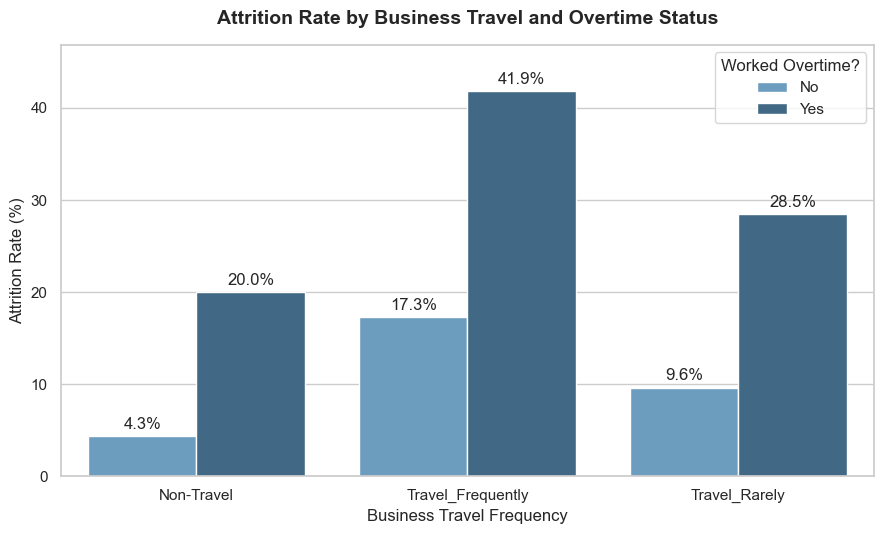

In [184]:
travel_ot_df = (
    employee.groupby(['BusinessTravel', 'OverTime'])['Attrition'].mean() * 100
).reset_index()

# 2. Plot configuration
plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")

# Create a formal grouped bar chart
ax = sns.barplot(
    data=travel_ot_df,
    x='BusinessTravel',
    y='Attrition',
    hue='OverTime',
    palette='Blues_d' # Ensures strong visual separation and contrast on a white grid
)

# 3. Formal Aesthetics
plt.title('Attrition Rate by Business Travel and Overtime Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Business Travel Frequency', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)

# Ensure the Y-axis accommodates the labels and percentages cleanly
plt.ylim(0, max(travel_ot_df['Attrition']) + 5)
plt.legend(title='Worked Overtime?')

# Add exact percentage labels to the top of each bar for executive precision
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

This plot clearly shows that people who worked overtime and travelled frequently has the highest attrition rate. This might be one the main driver of attrition as the workload and stress is high due to these reasons.

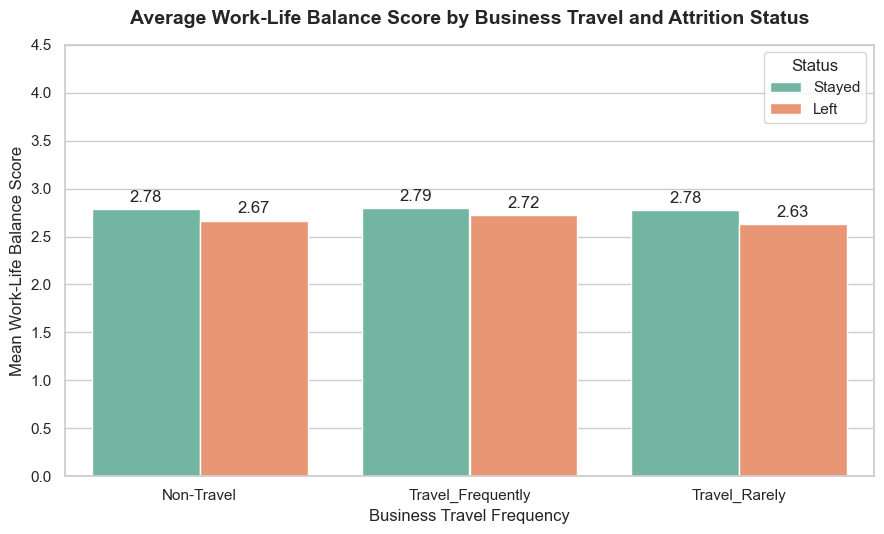

In [185]:
wlb_travel_df = employee.groupby(['BusinessTravel', 'Attrition'])['WorkLifeBalance'].mean().reset_index()
wlb_travel_df['Attrition'] = wlb_travel_df['Attrition'].map({0: 'Stayed', 1: 'Left'})

# 2. Plot configuration
plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")

# Create a formal grouped bar chart
ax = sns.barplot(
    data=wlb_travel_df,
    x='BusinessTravel',
    y='WorkLifeBalance',
    hue='Attrition',
    palette={'Stayed': '#66c2a5', 'Left': '#fc8d62'}, # Non-white distinct palette for white grid contrast
    errorbar=None
)

# 3. Formal Aesthetics
plt.title('Average Work-Life Balance Score by Business Travel and Attrition Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Business Travel Frequency', fontsize=12)
plt.ylabel('Mean Work-Life Balance Score', fontsize=12)

# Set Y-axis limits slightly above the max score (4.0) to accommodate labels comfortably
plt.ylim(0, 4.5)
plt.legend(title='Status', loc='upper right')

# Add exact average score labels to the top of each bar for auditing precision
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

So, average work-life-balance score isn't affected by business travel frequency.

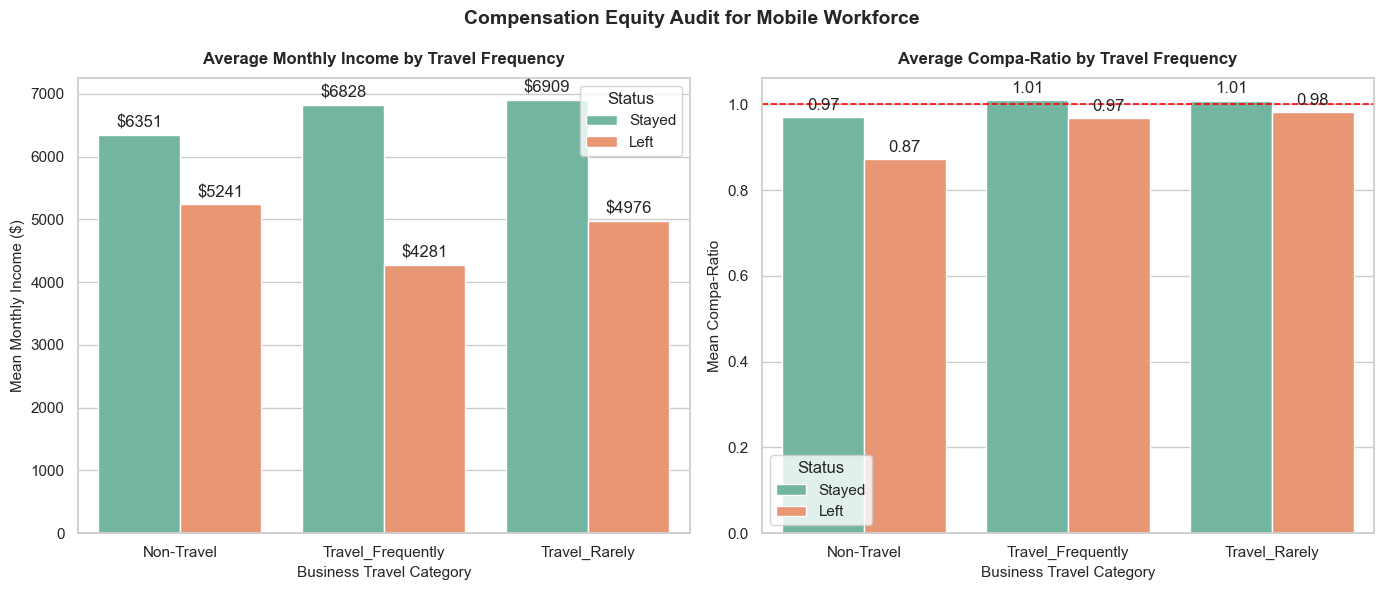

In [189]:
comp_travel_df = employee.groupby(['BusinessTravel', 'Attrition'])[['MonthlyIncome', 'CompensationRatio']].mean().reset_index()
comp_travel_df['Attrition'] = comp_travel_df['Attrition'].map({0: 'Stayed', 1: 'Left'})

# 2. Plot configuration: Set up a 1-row, 2-column figure layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# --- Subplot 1: Monthly Income Breakdown ---
sns.barplot(
    data=comp_travel_df,
    x='BusinessTravel',
    y='MonthlyIncome',
    hue='Attrition',
    palette={'Stayed': '#66c2a5', 'Left': '#fc8d62'},
    ax=axes[0]
)
axes[0].set_title('Average Monthly Income by Travel Frequency', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Business Travel Category', fontsize=11)
axes[0].set_ylabel('Mean Monthly Income ($)', fontsize=11)
axes[0].legend(title='Status')

# Add values on top of income bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='$%.0f', padding=3)

# --- Subplot 2: Compa-Ratio Breakdown ---
sns.barplot(
    data=comp_travel_df,
    x='BusinessTravel',
    y='CompensationRatio',
    hue='Attrition',
    palette={'Stayed': '#66c2a5', 'Left': '#fc8d62'},
    ax=axes[1]
)
axes[1].set_title('Average Compa-Ratio by Travel Frequency', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Business Travel Category', fontsize=11)
axes[1].set_ylabel('Mean Compa-Ratio', fontsize=11)
axes[1].legend(title='Status')

# Reference line for internal market rate baseline (1.0)
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='Peer Average')

# Add values on top of comp-ratio bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3)

# 3. Formal Aesthetics
plt.suptitle('Compensation Equity Audit for Mobile Workforce', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Non-travellers has the highest monthly income among who left. So, if someone getting paid similarly or better, even by not travelling or less travelling then this is not a fair compensation for those who travel frequently.

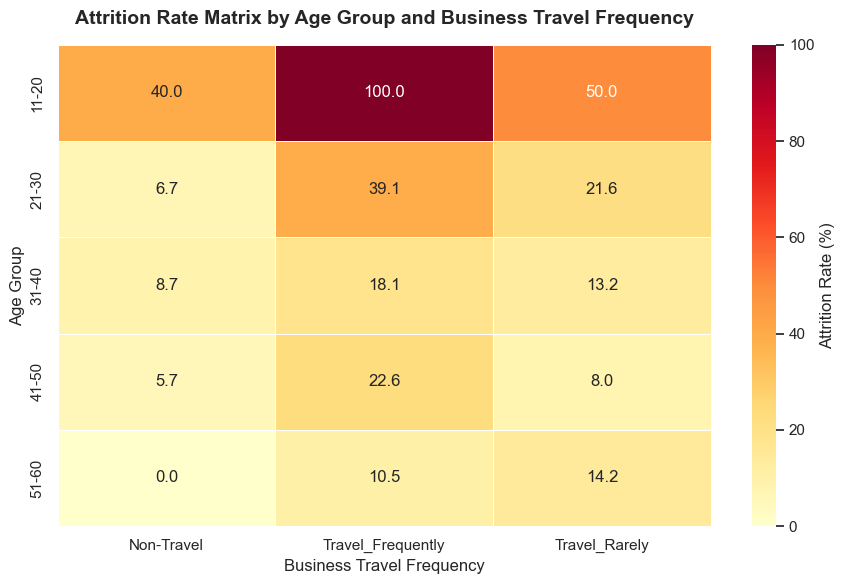

In [190]:
heatmap_df = (
    employee.groupby(['Age_Group', 'BusinessTravel'], observed=False)['Attrition'].mean() * 100
).unstack()

# 2. Plot configuration
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Create a formal matrix heatmap with non-white sequential shading for contrast
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd', # Yellow-Orange-Red gradient to emphasize high-risk zones
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Attrition Rate (%)'}
)

# 3. Formal Aesthetics
plt.title('Attrition Rate Matrix by Age Group and Business Travel Frequency', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Business Travel Frequency', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

plt.tight_layout()
plt.show()

The above matrix shows that business travel is a strong driver of attrition for most people, with the highest catastrophic rate of 100% attrition for the 11-20 age group and 39.1% attrition for the 21-30 age group. On the other hand, the older age groups show greater resistance to travel needs, with travel-related attrition for the 51-60 age group being only 10.5%. The unique pattern established here shows that travel pressures affect younger workers more, necessitating changes in the travel policies of workers below 30 years old.